# Práctica 4




## 1. Ingreso y Limpieza de Datos

In [ ]:
# ===========================================
# CONFIGURACIÓN INICIAL Y PREPARACIÓN DE DATOS
# ===========================================

# Importación de librerías
import pandas as pd
import glob
import os
from datetime import datetime
import csv

# Conexión con Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ------------------------------
# CONFIGURACIÓN DE RUTAS
# ------------------------------

# Ruta del archivo ZIP comprimido en Drive
ZIP_PATH = "/content/drive/MyDrive/ecobici.zip"

# Directorio donde se descomprimirán los archivos
INPUT_FOLDER = "/content/ecobici"

# Archivos de salida
OUTPUT_FILE = "/content/ecobici_merged_clean.csv"
LOG_FILE = "/content/ecobici_merge_clean_log.txt"
TEMP_FOLDER = "/content/ecobici_temp"

# Tamaño de chunks para procesamiento
CHUNK_SIZE = 100000

# ------------------------------
# PREPARACIÓN DEL ENTORNO
# ------------------------------

# Descompresión del archivo ZIP
if not os.path.exists(INPUT_FOLDER):
    print("Iniciando descompresión de archivos...")
    !unzip "{ZIP_PATH}" -d "/content/"
    print(f"Descompresión completada en: {INPUT_FOLDER}")
else:
    print(f"Directorio de datos ya existe: {INPUT_FOLDER}")

# Creación de directorio temporal para procesamiento intermedio
os.makedirs(TEMP_FOLDER, exist_ok=True)

# ------------------------------
# VERIFICACIÓN INICIAL
# ------------------------------

# Listar archivos disponibles para procesamiento
archivos_disponibles = os.listdir(INPUT_FOLDER)
print("\nArchivos detectados (muestra de 5):")
for archivo in archivos_disponibles[:5]:
    print(f"- {archivo}")
print(f"\nTotal de archivos CSV: {len(archivos_disponibles)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directorio de datos ya existe: /content/ecobici

Archivos detectados (muestra de 5):
- 2012-07.csv
- 2024-10.csv
- 2019-08.csv
- 2013-08.csv
- 2023-02.csv

Total de archivos CSV: 182


In [ ]:
# ===========================================
# CONFIGURACIÓN DEL SISTEMA DE LOGGING
# ===========================================

def setup_logging():

    # ------------------------------
    # PREPARACIÓN DE DIRECTORIOS
    # ------------------------------

    # Crear directorio en Drive si no existe
    try:
        os.makedirs(DRIVE_PATH, exist_ok=True)
    except Exception as dir_error:
        print(f"Error al crear directorio en Drive: {str(dir_error)}")
        raise

    # ------------------------------
    # INICIALIZACIÓN DE LOG LOCAL
    # ------------------------------

    log_header = f"""
    {'='*60}
    PROCESAMIENTO DATOS ECOBICI
    Inicio: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
    {'='*60}
    """

    try:
        with open(LOG_FILE, 'w', encoding='utf-8') as log_file:
            log_file.write(log_header)
        print(f"Archivo log creado en: {LOG_FILE}")
    except IOError as io_error:
        print(f"Error crítico: No se pudo crear archivo log - {str(io_error)}")
        raise

    # ------------------------------
    # BACKUP EN GOOGLE DRIVE
    # ------------------------------

    try:
        # Montar Drive
        from google.colab import drive
        drive.mount('/content/drive', force_remount=True)
        drive_log_path = os.path.join(DRIVE_PATH, os.path.basename(LOG_FILE))
        !cp "{LOG_FILE}" "{drive_log_path}"

        print(f"Copia de respaldo guardada en Drive: {drive_log_path}")

    except Exception as drive_error:
        print(f"Advertencia: No se pudo guardar en Drive - {str(drive_error)}")

In [ ]:
# ===========================================
# FUNCIONES DE TRANSFORMACIÓN Y PROCESAMIENTO
# ===========================================

def standardize_date_format(df):

    date_columns = ['Fecha_Retiro', 'Fecha_Arribo']

    for col in date_columns:
        if col in df.columns:
            # Muestra representativa para diagnóstico
            sample = df[col].dropna().head(1).iloc[0] if not df[col].dropna().empty else None

            if sample:
                try:
                    # Intenta los formatos más comunes en orden de prioridad
                    date_formats = ['%d/%m/%Y', '%d-%m-%Y', '%Y-%m-%d', '%m/%d/%Y']

                    for fmt in date_formats:
                        try:
                            df[col] = pd.to_datetime(df[col], format=fmt, errors='raise')
                            break
                        except ValueError:
                            continue

                    # Formateo final consistente
                    df[col] = df[col].dt.strftime('%Y-%m-%d')

                except Exception as e:
                    log_message(f"Error en formato de fecha {col}: {str(e)}")
                    df[col] = pd.to_datetime(df[col], errors='coerce').dt.strftime('%Y-%m-%d')

    return df

def standardize_time_format(df):

    time_columns = ['Hora_Retiro', 'Hora_Arribo']

    for col in time_columns:
        if col in df.columns:
            try:
                # Elimina milisegundos y espacios
                df[col] = (
                    df[col].astype(str)
                    .str.strip()
                    .str.replace(r'\.\d+', '', regex=True)
                    .str.extract(r'(\d{2}:\d{2}:\d{2})', expand=False)
                    .fillna('00:00:00')
                )
            except Exception as e:
                log_message(f"Error en formato de hora {col}: {str(e)}")
                df[col] = df[col].astype(str)

    return df

def process_year(year):

    year_files = sorted(glob.glob(os.path.join(INPUT_FOLDER, f'{year}-*.csv')))
    if not year_files:
        log_message(f"No se encontraron archivos para el año {year}")
        return None

    temp_output = os.path.join(TEMP_FOLDER, f'merged_{year}.csv')
    year_rows = 0

    # Verificación de existencia previa
    if os.path.exists(temp_output):
        existing_rows = len(pd.read_csv(temp_output))
        log_message(f"Archivo {year} ya procesado previamente ({existing_rows} filas)")
        return existing_rows

    try:
        with open(temp_output, 'w', encoding='utf-8') as f_out:
            for file_idx, file in enumerate(year_files):
                for chunk_idx, chunk in enumerate(pd.read_csv(file, chunksize=CHUNK_SIZE, dtype=str)):
                    # Optimización de memoria
                    chunk = chunk.astype({
                        'Genero_Usuario': 'category',
                        'Edad_Usuario': 'float32'
                    }, errors='ignore')

                    # Estandarización
                    chunk = standardize_date_format(chunk)
                    chunk = standardize_time_format(chunk)

                    # Escritura
                    header = (file_idx == 0 and chunk_idx == 0)
                    chunk.to_csv(f_out, header=header, index=False, mode='a')
                    year_rows += len(chunk)

                    # Log periódico
                    if (chunk_idx + 1) % 10 == 0:
                        log_message(f"Procesando {os.path.basename(file)} - Lote {chunk_idx + 1} ({year_rows} filas acumuladas)")

    except Exception as e:
        log_message(f"Error crítico al procesar {year}: {str(e)}")
        return None

    log_message(f"Procesamiento completado para {year} - Total: {year_rows} filas")
    return year_rows

def safe_read_csv(filepath, chunk_size=CHUNK_SIZE):

    try:
        chunks = []
        skipped = 0
        for chunk in pd.read_csv(filepath, chunksize=chunk_size, engine='python', on_bad_lines='warn'):
            valid = ~chunk.isnull().all(axis=1)
            skipped += sum(~valid)
            chunks.append(chunk[valid])

        return pd.concat(chunks, ignore_index=True), skipped

    except Exception as e:
        log_message(f"Error al leer {filepath}: {str(e)}")
        return pd.DataFrame(), 0

def merge_year_files():

    year_files = sorted(glob.glob(os.path.join(TEMP_FOLDER, 'merged_*.csv')))
    if not year_files:
        log_message("No hay archivos temporales para combinar")
        return 0

    total_rows = 0
    error_log = []

    with open(OUTPUT_FILE, 'w', encoding='utf-8') as f_out:
        for file_idx, file in enumerate(year_files):
            try:
                for chunk in pd.read_csv(file, chunksize=CHUNK_SIZE, engine='python'):
                    if not chunk.empty:
                        header = (file_idx == 0 and total_rows == 0)
                        chunk.to_csv(f_out, header=header, index=False, mode='a')
                        total_rows += len(chunk)
            except Exception as e:
                error_log.append(f"{file}: {str(e)}")
                continue

    if error_log:
        error_path = os.path.join(DRIVE_PATH, "merge_errors.log")
        with open(error_path, 'w') as f_err:
            f_err.write("\n".join(error_log))
        log_message(f"Errores guardados en {error_path}")

    return total_rows

In [ ]:
# ===========================================
# FUNCIÓN PRINCIPAL DE EJECUCIÓN
# ===========================================
def main():

    # Inicialización
    setup_logging()
    start_time = datetime.now()
    total_rows = 0

    try:
        log_message("Inicio del procesamiento de datos Ecobici")
        log_message(f"Directorio de entrada: {INPUT_FOLDER}")
        log_message(f"Directorio temporal: {TEMP_FOLDER}")

        # ----------------------------------
        # DETECCIÓN DE ARCHIVOS EXISTENTES
        # ----------------------------------
        existing_files = glob.glob(os.path.join(TEMP_FOLDER, 'merged_*.csv'))

        if existing_files:
            log_message(f"\nArchivos temporales detectados ({len(existing_files)}):")
            for file_path in sorted(existing_files):
                file_name = os.path.basename(file_path)
                file_size = os.path.getsize(file_path)/(1024*1024)
                log_message(f"- {file_name} ({file_size:.1f} MB)")

        # ----------------------------------
        # PROCESAMIENTO POR AÑO
        # ----------------------------------
        year_stats = {}
        years_to_process = sorted(range(2010, 2026))

        for year in years_to_process:
            log_message(f"\nProcesando año {year}...")

            # Verificar si ya existe el archivo temporal
            temp_file = os.path.join(TEMP_FOLDER, f'merged_{year}.csv')
            if os.path.exists(temp_file):
                existing_count = len(pd.read_csv(temp_file))
                log_message(f"Archivo existente detectado - {existing_count} registros")
                year_stats[year] = existing_count
                continue

            # Procesar año si no existe
            processed_rows = process_year(year)
            if processed_rows:
                year_stats[year] = processed_rows

        # ----------------------------------
        # CONSOLIDACIÓN FINAL
        # ----------------------------------
        if year_stats:
            total_rows = merge_year_files()

            # Validación y guardado en Drive
            if validate_merged_file():
                log_message("Validación del archivo final exitosa")
            else:
                log_message("Advertencia: Problemas en validación (archivo guardado igualmente)")
        else:
            log_message("\nNo se requirió procesamiento nuevo - usando archivos existentes")
            total_rows = sum(year_stats.values())

        # ----------------------------------
        # REPORTE FINAL
        # ----------------------------------
        processing_time = (datetime.now() - start_time).total_seconds() / 60

        log_message("\nRESUMEN FINAL DEL PROCESO")
        log_message("="*50)
        log_message(f"Total de registros procesados: {total_rows:,}")
        log_message(f"Tiempo total de ejecución: {processing_time:.1f} minutos")

        log_message("\nDETALLE POR AÑO:")
        for year, count in sorted(year_stats.items()):
            log_message(f"- {year}: {count:,} registros")

        log_message("\nProceso completado exitosamente")

    except KeyboardInterrupt:
        log_message("Proceso interrumpido por el usuario")
        raise

    except Exception as e:
        log_message(f"Error crítico durante la ejecución: {str(e)}")
        raise

# Punto de entrada principal
if __name__ == "__main__":
    main()

Archivo log creado en: /content/ecobici_merge_clean_log.txt
Mounted at /content/drive
Copia de respaldo guardada en Drive: /content/drive/MyDrive/ecobici_project/ecobici_merge_clean_log.txt
Inicio del procesamiento de datos Ecobici
Directorio de entrada: /content/ecobici
Directorio temporal: /content/ecobici_temp

Archivos temporales detectados (16):
- merged_2010.csv (57.6 MB)
- merged_2011.csv (174.1 MB)
- merged_2012.csv (188.2 MB)
- merged_2013.csv (452.8 MB)
- merged_2014.csv (553.1 MB)
- merged_2015.csv (641.0 MB)
- merged_2016.csv (632.9 MB)
- merged_2017.csv (663.8 MB)
- merged_2018.csv (598.8 MB)
- merged_2019.csv (593.4 MB)
- merged_2020.csv (287.8 MB)
- merged_2021.csv (303.3 MB)
- merged_2022.csv (371.0 MB)
- merged_2023.csv (774.6 MB)
- merged_2024.csv (1595.7 MB)
- merged_2025.csv (407.7 MB)

Procesando año 2010...
Archivo existente detectado - 841078 registros

Procesando año 2011...


<ipython-input-22-d3fda2e37507>:50: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  existing_count = len(pd.read_csv(temp_file))


Archivo existente detectado - 2542962 registros

Procesando año 2012...
Archivo existente detectado - 2737916 registros

Procesando año 2013...
Archivo existente detectado - 6515327 registros

Procesando año 2014...


<ipython-input-22-d3fda2e37507>:50: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  existing_count = len(pd.read_csv(temp_file))


Archivo existente detectado - 7952246 registros

Procesando año 2015...


...

<ipython-input-22-d3fda2e37507>:50: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  existing_count = len(pd.read_csv(temp_file))


Archivo existente detectado - 9498043 registros

Procesando año 2018...


<ipython-input-22-d3fda2e37507>:50: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  existing_count = len(pd.read_csv(temp_file))


Archivo existente detectado - 8540257 registros

Procesando año 2019...
Error crítico durante la ejecución: Error tokenizing data. C error: Expected 9 fields in line 1381367, saw 10



ParserError: Error tokenizing data. C error: Expected 9 fields in line 1381367, saw 10


In [ ]:
# ===========================================
# CELDA PARA CORREGIR MERGE Y VALIDACIÓN (EJECUTAR ESTA SOLA)
# ===========================================
import pandas as pd
import os
from datetime import datetime

# Configuración
OUTPUT_FILE = "ecobici_merged_clean.csv"
DRIVE_PATH = "/content/drive/MyDrive/ecobici_project"
TEMP_FOLDER = "ecobici_temp"
CHUNK_SIZE = 100000

# Función de merge
def merge_year_files_fixed():

    year_files = sorted(glob.glob(os.path.join(TEMP_FOLDER, 'merged_*.csv')))

    if not year_files:
        print("No hay archivos temporales. Ejecuta process_year() primero.")
        return 0

    print(f"\nUniendo {len(year_files)} archivos anuales...")
    total_rows = 0

    with open(OUTPUT_FILE, 'w', encoding='utf-8') as f_out:
        for i, file in enumerate(year_files):
            try:
                for chunk in pd.read_csv(
                    file,
                    chunksize=CHUNK_SIZE,
                    engine='python',
                    on_bad_lines='warn',
                    dtype={'Genero_Usuario': 'category'}
                ):
                    if not chunk.empty:
                        # Verificación de columnas
                        date_cols = [c for c in ['Fecha_Retiro', 'Fecha_Arribo'] if c in chunk.columns]
                        if date_cols:
                            chunk[date_cols] = chunk[date_cols].apply(pd.to_datetime, errors='coerce')

                        chunk.to_csv(
                            f_out,
                            header=(i == 0 and total_rows == 0),
                            index=False,
                            mode='a'
                        )
                        total_rows += len(chunk)

                print(f"{os.path.basename(file)}: {total_rows:,} filas acumuladas")

            except Exception as e:
                print(f"Error en {file}: {str(e)}")
                continue

    print(f"\nMerge completado. Filas totales: {total_rows:,}")
    return total_rows

# Función de validación
def validate_and_save():
    """Valida y guarda en Drive"""
    from google.colab import drive

    try:
        if not os.path.exists(OUTPUT_FILE) or os.path.getsize(OUTPUT_FILE) == 0:
            print("Archivo vacío o no existe")
            return False

        sample = pd.read_csv(OUTPUT_FILE, nrows=5)
        print("\nMuestra del archivo final:")
        display(sample)

        # Guardar en Drive
        drive.mount('/content/drive', force_remount=True)
        os.makedirs(DRIVE_PATH, exist_ok=True)
        drive_file = f"{DRIVE_PATH}/{os.path.basename(OUTPUT_FILE)}"
        !cp "{OUTPUT_FILE}" "{drive_file}"

        print(f"\n💾 Guardado en Drive: {drive_file}")
        return True

    except Exception as e:
        print(f"Error: {str(e)}")
        return False

# Ejecución
print("Iniciando corrección...")
total_rows = merge_year_files_fixed()
validate_and_save()
print("Proceso completado")

Iniciando corrección...

🔗 Uniendo 16 archivos anuales...
✅ merged_2010.csv: 841,078 filas acumuladas
✅ merged_2011.csv: 3,384,040 filas acumuladas
✅ merged_2012.csv: 6,121,956 filas acumuladas
✅ merged_2013.csv: 12,637,283 filas acumuladas
✅ merged_2014.csv: 20,589,529 filas acumuladas
✅ merged_2015.csv: 29,781,604 filas acumuladas
✅ merged_2016.csv: 38,851,146 filas acumuladas
✅ merged_2017.csv: 48,349,189 filas acumuladas
✅ merged_2018.csv: 56,889,446 filas acumuladas


Se han truncado las últimas 5000 líneas del flujo de salida.

  for chunk in pd.read_csv(
<ipython-input-18-e303cfe94a54>:29: ParserWarning: Skipping line 2132000: Expected 9 fields in line 2132000, saw 10

  for chunk in pd.read_csv(
<ipython-input-18-e303cfe94a54>:29: ParserWarning: Skipping line 2132001: Expected 9 fields in line 2132001, saw 10

  for chunk in pd.read_csv(
<ipython-input-18-e303cfe94a54>:29: ParserWarning: Skipping line 2132002: Expected 9 fields in line 2132002, saw 10

  for chunk in pd.read_csv(
<ipython-input-18-e303cfe94a54>:29: ParserWarning: Skipping line 2132003: Expected 9 fields in line 2132003, saw 10

  for chunk in pd.read_csv(
<ipython-input-18-e303cfe94a54>:29: ParserWarning: Skipping line 2132004: Expected 9 fields in line 2132004, saw 10

  for chunk in pd.read_csv(
<ipython-input-18-e303cfe94a54>:29: ParserWarning: Skipping line 2132005: Expected 9 fields in line 2132005, saw 10

  for chunk in pd.read_csv(
<ipython-input-18-e303cfe94a54>:29: Pars

✅ merged_2019.csv: 64,552,591 filas acumuladas


Se han truncado las últimas 5000 líneas del flujo de salida.

  for chunk in pd.read_csv(
<ipython-input-18-e303cfe94a54>:29: ParserWarning: Skipping line 2876672: Expected 9 fields in line 2876672, saw 10

  for chunk in pd.read_csv(
<ipython-input-18-e303cfe94a54>:29: ParserWarning: Skipping line 2876673: Expected 9 fields in line 2876673, saw 10

  for chunk in pd.read_csv(
<ipython-input-18-e303cfe94a54>:29: ParserWarning: Skipping line 2876674: Expected 9 fields in line 2876674, saw 10

  for chunk in pd.read_csv(
<ipython-input-18-e303cfe94a54>:29: ParserWarning: Skipping line 2876675: Expected 9 fields in line 2876675, saw 10

  for chunk in pd.read_csv(
<ipython-input-18-e303cfe94a54>:29: ParserWarning: Skipping line 2876676: Expected 9 fields in line 2876676, saw 10

  for chunk in pd.read_csv(
<ipython-input-18-e303cfe94a54>:29: ParserWarning: Skipping line 2876677: Expected 9 fields in line 2876677, saw 10

  for chunk in pd.read_csv(
<ipython-input-18-e303cfe94a54>:29: Pars

✅ merged_2020.csv: 68,317,594 filas acumuladas
✅ merged_2021.csv: 72,624,168 filas acumuladas
✅ merged_2022.csv: 77,837,980 filas acumuladas
✅ merged_2023.csv: 88,206,696 filas acumuladas
✅ merged_2024.csv: 109,487,931 filas acumuladas
✅ merged_2025.csv: 114,875,912 filas acumuladas

🎉 Merge completado. Filas totales: 114,875,912

📄 Muestra del archivo final:


,M,28,0069,85,2010-02-16,12:42:32,85.1,2010-02-16.1,12:45:37
0,M,30,11,85,2010-02-16,12:53:29,26,2010-02-16,13:22:23
1,M,37,43,85,2010-02-16,13:21:46,13,2010-02-16,13:49:47
2,M,37,826,22,2010-02-16,14:06:40,85,2010-02-16,14:23:13
3,M,19,662,27,2010-02-16,15:31:15,74,2010-02-16,16:29:17
4,F,25,8,85,2010-02-16,16:31:53,20,2010-02-16,16:49:26


Mounted at /content/drive

💾 Guardado en Drive: /content/drive/MyDrive/ecobici_project/ecobici_merged_clean.csv
✅ Proceso completado


In [ ]:
# ===========================================
# CELDA PARA DESCARGAR EL ARCHIVO DESDE COLAB
# ===========================================
from google.colab import files
import os

# Verificar que el archivo existe en el entorno local de Colab
FILE_NAME = "ecobici_merged_clean.csv"

if os.path.exists(FILE_NAME):
    # Forzar la descarga del archivo
    files.download(FILE_NAME)
    print(f"Descarga iniciada: {FILE_NAME}")
else:
    print(f"Error: El archivo {FILE_NAME} no existe en el entorno local de Colab")
    print("Ejecuta primero la celda de merge y validación")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descarga iniciada: ecobici_merged_clean.csv


## 2. Modulación no Supervisada, TAD Continuas.

In [ ]:
# ======================================
# INSTALACIÓN DE LIBRERÍAS
# ======================================
print("Instalando/Actualizando librerías...")

!pip install plotly --quiet
!pip install scikit-learn --upgrade --quiet
!pip install tslearn --quiet

print("Librerías listas!")

Instalando/Actualizando librerías...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 7.0 MB/s eta 0:00:00
Librerías listas!


In [ ]:
# ======================
# CONFIGURACION INICIAL Y PREPARACION DE DATOS
# ======================

# Importacion de librerias
import pandas as pd
import numpy as np
import os
import datetime as dt
import warnings
from sklearn.exceptions import DataConversionWarning
import zipfile
from google.colab import drive, files

# Configuracion de advertencias
warnings.filterwarnings('ignore', category=DataConversionWarning)
warnings.filterwarnings('ignore')

# Librerias para visualizacion
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Configuracion de visualizacion
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 9

# Configuracion de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ======================
# CONFIGURACION DE RUTAS
# ======================

# Ruta del archivo ZIP en Google Drive
ZIP_PATH = "/content/drive/MyDrive/ecobici_merged_clean.csv.zip"

# Directorio para archivos descomprimidos
INPUT_FOLDER = "/content/ecobici_data"

# Archivos de entrada/salida
INPUT_FILE = os.path.join(INPUT_FOLDER, "ecobici_merged_clean.csv")
OUTPUT_FILE = "ecobici_transformed.csv"

# Parametros de procesamiento
CHUNK_SIZE = 100_000

# ======================
# PREPARACION DEL ENTORNO
# ======================

# Montar Google Drive
print("Montando Google Drive...")
drive.mount('/content/drive')

# Crear directorio para datos si no existe
os.makedirs(INPUT_FOLDER, exist_ok=True)

# Descomprimir archivo ZIP si existe
if os.path.exists(ZIP_PATH):
    print("Descomprimiendo archivo ZIP...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(INPUT_FOLDER)
    print(f"Archivos descomprimidos en: {INPUT_FOLDER}")
else:
    print(f"Advertencia: No se encontro el archivo ZIP en {ZIP_PATH}")

# Verificar archivo de entrada
if os.path.exists(INPUT_FILE):
    print(f"Archivo de entrada encontrado: {INPUT_FILE}")
else:
    print(f"Error: No se encontro el archivo de entrada {INPUT_FILE}")
    print("Por favor verifique que el archivo ZIP contenga el CSV esperado")

# ======================
# FUNCION DE DESCARGA
# ======================

def descargar_resultado():

    if os.path.exists(OUTPUT_FILE):
        print(f"Iniciando descarga de {OUTPUT_FILE}...")
        files.download(OUTPUT_FILE)
        print("Descarga completada")
    else:
        print(f"Error: No se encontro el archivo {OUTPUT_FILE}")
        print("Por favor ejecute primero el proceso de transformacion")

print("\nConfiguracion completada. Sistema listo para procesamiento.")
print("Hora de inicio:", dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S'))

Montando Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Descomprimiendo archivo ZIP...
Archivos descomprimidos en: /content/ecobici_data
Archivo de entrada encontrado: /content/ecobici_data/ecobici_merged_clean.csv

Configuracion completada. Sistema listo para procesamiento.
Hora de inicio: 2025-05-11 20:14:31



INICIANDO ANALISIS ESPECIFICO PARA ECOBICI...

ANALISIS PARA DATOS ECOBICI
Tamaño de muestra objetivo: 500,000 registros

Leyendo estructura del archivo...

Muestra inicial del archivo:


,M,28,0069,85,2010-02-16,12:42:32,85.1,2010-02-16.1,12:45:37
0,M,30,11,85,2010-02-16,12:53:29,26,2010-02-16,13:22:23
1,M,37,43,85,2010-02-16,13:21:46,13,2010-02-16,13:49:47
2,M,37,826,22,2010-02-16,14:06:40,85,2010-02-16,14:23:13
3,M,19,662,27,2010-02-16,15:31:15,74,2010-02-16,16:29:17
4,F,25,8,85,2010-02-16,16:31:53,20,2010-02-16,16:49:26



Advertencia: No se encontraron columnas esperadas: ['Genero_Usuario', 'Edad_Usuario', 'Bici', 'Ciclo_Estacion_Retiro', 'Fecha_Retiro', 'Hora_Retiro', 'Ciclo_Estacion_Arribo', 'Fecha_Arribo', 'Hora_Arribo']
Asumiendo que el archivo no tiene encabezado...

Muestra cargada: 500,000 registros
Columnas disponibles: ['Genero_Usuario', 'Edad_Usuario', 'Bici', 'Ciclo_Estacion_Retiro', 'Fecha_Retiro', 'Hora_Retiro', 'Ciclo_Estacion_Arribo', 'Fecha_Arribo', 'Hora_Arribo']

ESTADISTICAS DESCRIPTIVAS:

Variables numéricas:


,count,mean,std,min,25%,50%,75%,max
Edad_Usuario,500000.00,34.44,10.11,16.00,27.00,32.00,40.00,80.00
Bici,500000.00,771.17,12979.38,1.00,301.00,602.00,898.00,990004.00
Ciclo_Estacion_Retiro,500000.00,44.98,25.18,1.00,23.00,46.00,67.00,1001.00
Ciclo_Estacion_Arribo,500000.00,45.36,26.67,1.00,23.00,47.00,68.00,1001.00



Variables categóricas:

Distribución para Genero_Usuario:


...


Distribución para Fecha_Arribo:


,count
Fecha_Arribo,
2010-10-08,5533
2010-10-13,5074
2010-10-12,5066
2010-10-15,4814
2010-10-05,4790
2010-09-30,4773
2010-10-14,4763
2010-09-29,4691
2010-10-06,4661



Distribución para Hora_Arribo:


,count
Hora_Arribo,
16:36:25,28
16:04:06,28
09:03:59,27
09:17:17,26
09:06:41,26
09:02:33,26
09:03:56,26
08:57:18,26
19:12:34,26



GENERANDO VISUALIZACIONES...


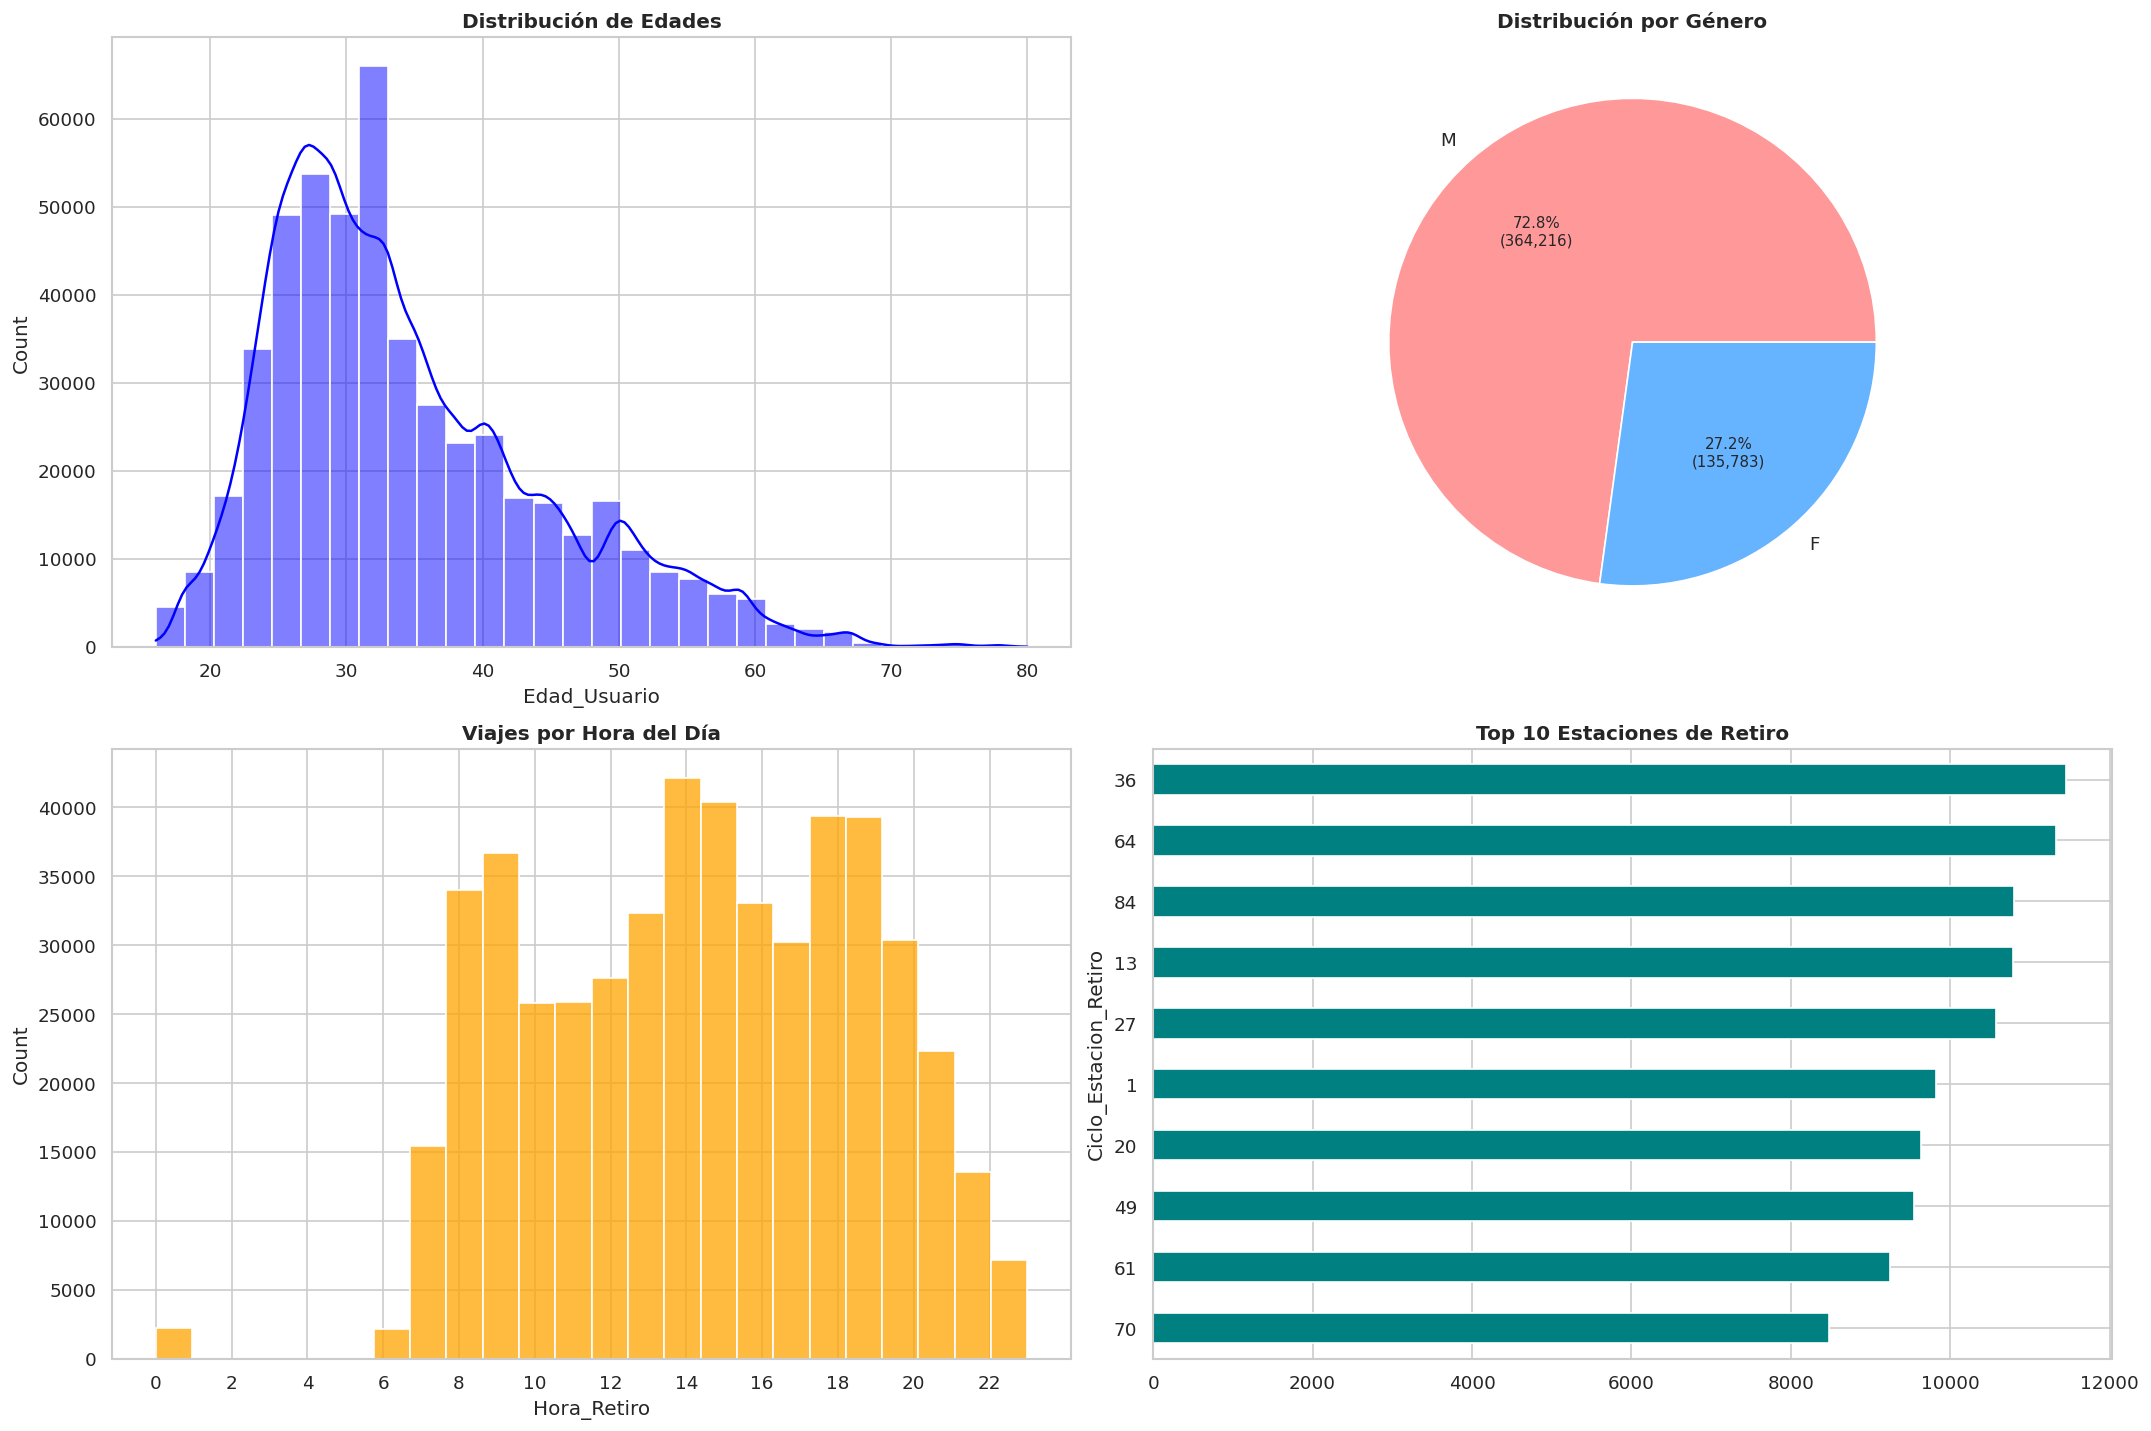


ANALISIS COMPLETADO CON EXITO


In [ ]:
# ===========================
# FUNCION DE ANALISIS PARA DATOS ECOBICI
# ===========================
def ecobici_analysis(input_file, sample_size=500000, random_state=42):

    # Verificación inicial
    if not os.path.exists(input_file):
        print(f"Error: Archivo no encontrado en {input_file}")
        return

    print("\nANALISIS PARA DATOS ECOBICI")
    print("="*60)
    print(f"Tamaño de muestra objetivo: {sample_size:,} registros\n")

    # Columnas específicas de Ecobici (con nombres exactos)
    ECOBICI_COLS = {
        'Genero_Usuario': 'Genero_Usuario',
        'Edad_Usuario': 'Edad_Usuario',
        'Bici': 'Bici',
        'Ciclo_Estacion_Retiro': 'Ciclo_Estacion_Retiro',
        'Fecha_Retiro': 'Fecha_Retiro',
        'Hora_Retiro': 'Hora_Retiro',
        'Ciclo_Estacion_Arribo': 'Ciclo_Estacion_Arribo',
        'Fecha_Arribo': 'Fecha_Arribo',
        'Hora_Arribo': 'Hora_Arribo'
    }

    try:
        # ----------------------------------
        # LECTURA DEL ARCHIVO
        # ----------------------------------
        print("Leyendo estructura del archivo...")

        # Leer las primeras filas
        test_df = pd.read_csv(input_file, nrows=5)
        print("\nMuestra inicial del archivo:")
        display(test_df.head())

        # Verificar si las columnas coinciden
        missing_cols = [col for col in ECOBICI_COLS if col not in test_df.columns]
        if missing_cols:
            print(f"\nAdvertencia: No se encontraron columnas esperadas: {missing_cols}")
            print("Asumiendo que el archivo no tiene encabezado...")

            # Releer con nombres de columnas explícitos
            df_sample = pd.read_csv(input_file,
                                   header=None,
                                   names=list(ECOBICI_COLS.values()),
                                   nrows=sample_size)
        else:
            # Leer normalmente si tiene encabezado
            df_sample = pd.read_csv(input_file,
                                   usecols=list(ECOBICI_COLS.keys()),
                                   nrows=sample_size)

        print(f"\nMuestra cargada: {len(df_sample):,} registros")
        print("Columnas disponibles:", df_sample.columns.tolist())

        # ----------------------------------
        # ANALISIS ESTADISTICO
        # ----------------------------------
        print("\nESTADISTICAS DESCRIPTIVAS:")
        print("="*60)

        # Análisis numérico
        print("\nVariables numéricas:")
        numeric_cols = df_sample.select_dtypes(include=['int64', 'float64']).columns
        if len(numeric_cols) > 0:
            display(df_sample[numeric_cols].describe().T.style.background_gradient(cmap='Blues').format("{:.2f}"))
        else:
            print("No se encontraron variables numéricas")

        # Análisis categórico
        print("\nVariables categóricas:")
        categorical_cols = df_sample.select_dtypes(include=['object', 'category']).columns
        if len(categorical_cols) > 0:
            for col in categorical_cols:
                print(f"\nDistribución para {col}:")
                display(df_sample[col].value_counts(dropna=False).head(10))
        else:
            print("No se encontraron variables categóricas")

        # ----------------------------------
        # VISUALIZACIONES
        # ----------------------------------
        print("\nGENERANDO VISUALIZACIONES...")
        print("="*60)

        plt.figure(figsize=(18, 12))

        # Gráfico 1: Edades
        if 'Edad_Usuario' in df_sample.columns:
            plt.subplot(2, 2, 1)
            sns.histplot(df_sample['Edad_Usuario'].dropna(), bins=30, kde=True, color='blue')
            plt.title('Distribución de Edades', fontweight='bold')

        # Gráfico 2: Género
        if 'Genero_Usuario' in df_sample.columns:
            plt.subplot(2, 2, 2)
            gender_counts = df_sample['Genero_Usuario'].value_counts()
            total = gender_counts.sum()

            def format_pct(p):
                return f'{p:.1f}%\n({int(p*total/100):,})'

            gender_counts.plot(
                kind='pie',
                autopct=format_pct,
                colors=['#ff9999','#66b3ff','#99ff99'],
                wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
            )
            plt.title('Distribución por Género', fontweight='bold')
            plt.ylabel('')

        # Gráfico 3: Horas
        if 'Hora_Retiro' in df_sample.columns:
            plt.subplot(2, 2, 3)
            try:
                hour = pd.to_datetime(df_sample['Hora_Retiro'], format='%H:%M:%S').dt.hour
                sns.histplot(hour.dropna(), bins=24, kde=False, color='orange')
                plt.xticks(range(0, 24, 2))
                plt.title('Viajes por Hora del Día', fontweight='bold')
            except:
                try:
                    hour = df_sample['Hora_Retiro'].str.split(':').str[0].astype(float)
                    sns.histplot(hour.dropna(), bins=24, kde=False, color='orange')
                    plt.xticks(range(0, 24, 2))
                    plt.title('Viajes por Hora (aproximada)', fontweight='bold')
                except Exception as e:
                    print(f"Error al procesar horas: {str(e)}")

        # Gráfico 4: Estaciones
        if 'Ciclo_Estacion_Retiro' in df_sample.columns:
            plt.subplot(2, 2, 4)
            try:
                top_stations = df_sample['Ciclo_Estacion_Retiro'].value_counts().head(10)
                top_stations.sort_values().plot(kind='barh', color='teal')
                plt.title('Top 10 Estaciones de Retiro', fontweight='bold')
            except Exception as e:
                print(f"Error al graficar estaciones: {str(e)}")

        plt.tight_layout()
        plt.show()

        print("\nANALISIS COMPLETADO CON EXITO")

    except Exception as e:
        print(f"\nERROR DURANTE EL ANALISIS: {str(e)}")
        print("Posibles soluciones:")
        print("1. Verifica que el archivo CSV tiene el formato correcto")
        print("2. Comprueba que los nombres de columnas coinciden")
        print("3. Prueba con un tamaño de muestra más pequeño")

print("\nINICIANDO ANALISIS ESPECIFICO PARA ECOBICI...")
ecobici_analysis(INPUT_FILE, sample_size=500000)

In [ ]:
# ===================================
# INICIALIZACION DE TRANSFORMADORES PARA ECOBICI
# ===================================
from sklearn.preprocessing import StandardScaler
import pandas as pd
import os

def initialize_ecobici_scaler():

    print("\nInicializando escalador para datos Ecobici...")

    # Nombres de columnas
    column_names = [
        'Genero_Usuario',
        'Edad_Usuario',
        'Bici',
        'Ciclo_Estacion_Retiro',
        'Fecha_Retiro',
        'Hora_Retiro',
        'Ciclo_Estacion_Arribo',
        'Fecha_Arribo',
        'Hora_Arribo'
    ]

    try:
        # Cargar solo la columna de edad con los nombres correctos
        sample = pd.read_csv(
            INPUT_FILE,
            header=None,
            names=column_names,
            usecols=['Edad_Usuario'],
            nrows=1000000
        )

        print(f"Registros cargados para entrenar escalador: {len(sample):,}")

        # Convertir a numérico y limpiar datos
        sample['Edad_Usuario'] = pd.to_numeric(sample['Edad_Usuario'], errors='coerce')

        # Filtrar edades razonables
        sample = sample[(sample['Edad_Usuario'] >= 15) & (sample['Edad_Usuario'] <= 80)]

        # Imputar valores faltantes con la mediana
        median_age = sample['Edad_Usuario'].median()
        sample['Edad_Usuario'] = sample['Edad_Usuario'].fillna(median_age)

        # Verificar que hay datos válidos
        if len(sample) == 0:
            raise ValueError("No hay datos válidos de edad después del filtrado")

        # Entrenar el escalador
        scaler = StandardScaler()
        scaler.fit(sample[['Edad_Usuario']])

        # Mostrar estadísticas
        print("\nEscalador configurado con éxito")
        print(f"Media de edad: {scaler.mean_[0]:.2f} años")
        print(f"Desviación estándar: {scaler.scale_[0]:.2f} años")
        print(f"Rango válido configurado: 15-80 años")
        print(f"Valores imputados con mediana: {median_age:.1f} años")

        return scaler

    except Exception as e:
        print(f"\nError al configurar el escalador: {str(e)}")
        print("Posibles causas:")
        print("- Falta importar StandardScaler (from sklearn.preprocessing import StandardScaler)")
        print("- El archivo no tiene el formato esperado")
        print("- La columna de edad no contiene valores numéricos válidos")
        print("- No hay registros en el rango de edad 15-80 años")
        return None

# Inicializar escalador específico para Ecobici
print("\nConfigurando transformadores para datos Ecobici...")
ecobici_scaler = initialize_ecobici_scaler()

if ecobici_scaler is not None:
    print("\nTransformador de edad listo para usar")
    print("Ejemplo de uso:")
    print("edad_escalada = ecobici_scaler.transform(datos[['Edad_Usuario']])")
else:
    print("\nNo se pudo inicializar el transformador. Verifique:")
    print(f"- Que el archivo {INPUT_FILE} existe")
    print("- Que contiene datos numéricos en la columna de edad")
    print("- Que hay registros con edades entre 15-80 años")


Configurando transformadores para datos Ecobici...

Inicializando escalador para datos Ecobici...
Registros cargados para entrenar escalador: 1,000,000

Escalador configurado con éxito
Media de edad: 34.16 años
Desviación estándar: 10.03 años
Rango válido configurado: 15-80 años
Valores imputados con mediana: 32.0 años

Transformador de edad listo para usar
Ejemplo de uso:
edad_escalada = ecobici_scaler.transform(datos[['Edad_Usuario']])


In [ ]:
# =================================
# FUNCIÓN PRINCIPAL DE TRANSFORMACIÓN
# =================================
def transform_chunk(chunk):

    # Filtrado por Edad
    mask = (chunk['Edad_Usuario'] >= 15) & (chunk['Edad_Usuario'] <= 80)
    chunk = chunk[mask].copy()
    if chunk.empty:
        print("Chunk vacío después de filtrar edades")
        return None

    # Procesamiento de Género
    chunk['Genero_Usuario'] = (
        chunk['Genero_Usuario']
        .fillna('?')
        .str.upper()
        .str[0]
        .where(lambda x: x.isin(['M', 'F', 'O']), '?')
    )

    # Transformación de Edad
    try:
        chunk['Edad_Estandarizada'] = scaler.transform(
            chunk[['Edad_Usuario']].fillna(scaler.mean_[0])
        )
    except Exception as e:
        print(f"Error en escalado de edad: {str(e)}")
        return None

    # Transformación circular de hora
    hora_ok = False
    try:

        horas = pd.to_datetime(chunk['Hora_Retiro'], format='%H:%M:%S', errors='coerce').dt.hour
        horas = horas.fillna(12)

        # Transformación circular (seno y coseno)
        radianes = horas * (2 * np.pi / 24)
        hora_seno, hora_coseno = np.sin(radianes), np.cos(radianes)
        hora_ok = True
    except Exception as e:
        print(f"Error en transformación horaria: {str(e)}")
        hora_seno = np.zeros(len(chunk))
        hora_coseno = np.zeros(len(chunk))

    # Creación de Variables Dummy
    genero_dummies = pd.get_dummies(
        chunk['Genero_Usuario'],
        prefix='Genero',
        dtype='int8',
        drop_first=True
    )

    # Categorización por Periodo
    condiciones = [
        horas.between(5, 11, inclusive='both'),
        horas.between(12, 16, inclusive='both'),
        horas.between(17, 20, inclusive='both'),
        (horas >= 21) | (horas < 5)
    ]
    chunk['Periodo_Dia'] = np.select(
        condiciones,
        ['Mañana', 'Tarde', 'Tarde-Noche', 'Noche'],
        default='Desconocido'
    )

    # Consolidación Final
    transformed_data = pd.concat([
        chunk[['Bici', 'Ciclo_Estacion_Retiro', 'Ciclo_Estacion_Arribo']].copy(),

        pd.DataFrame({
            'Edad_Estandarizada': chunk['Edad_Estandarizada'],
            'Hora_Seno': hora_seno,
            'Hora_Coseno': hora_coseno
        }),

        genero_dummies,

        pd.get_dummies(chunk['Periodo_Dia'], prefix='Periodo', dtype='int8')
    ], axis=1)

    return transformed_data

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA

# =================================
# PROCESAMIENTO POR CHUNKS
# =================================
def process_full_dataset(input_file, output_file, chunk_size=100000):

    print(f"\nIniciando procesamiento completo del archivo {input_file}")
    print(f"Tamaño de chunk: {chunk_size:,} registros")

    total_rows = 0
    first_chunk = True

    chunk_reader = pd.read_csv(
        input_file,
        header=None,
        names=[
            'Genero_Usuario',
            'Edad_Usuario',
            'Bici',
            'Ciclo_Estacion_Retiro',
            'Fecha_Retiro',
            'Hora_Retiro',
            'Ciclo_Estacion_Arribo',
            'Fecha_Arribo',
            'Hora_Arribo'
        ],
        chunksize=chunk_size
    )

    for i, chunk in enumerate(chunk_reader):
        # Transformar el chunk
        transformed = transform_chunk(chunk)

        if transformed is not None and not transformed.empty:
            total_rows += len(transformed)
            mode = 'w' if first_chunk else 'a'
            header = first_chunk
            transformed.to_csv(output_file, mode=mode, header=header, index=False)
            print(f"Chunk {i+1} procesado y guardado: {len(transformed):,} registros")
            first_chunk = False

    if total_rows > 0:
        print(f"\nProcesamiento completado. Total registros válidos: {total_rows:,}")
        print(f"Archivo guardado en: {output_file}")
        return pd.read_csv(output_file)
    else:
        print("\nNo se procesaron datos válidos")
        return None

# =================================
# ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)
# =================================
def apply_pca(data, n_components=2):

    print("\nAplicando Análisis de Componentes Principales...")

    # Seleccionar solo las características numéricas
    numeric_features = data.select_dtypes(include=['float64', 'int8', 'int32', 'int64']).columns
    X = data[numeric_features]

    # Aplicar PCA
    pca = PCA(n_components=n_components, random_state=42)
    principal_components = pca.fit_transform(X)

    # Crear DataFrame con los componentes
    pca_df = pd.DataFrame(data=principal_components,
                         columns=[f'PC_{i+1}' for i in range(n_components)])

    # Explicar varianza
    print(f"Varianza explicada por cada componente: {pca.explained_variance_ratio_}")
    print(f"Varianza total explicada: {sum(pca.explained_variance_ratio_):.2%}")

    return pca_df

# =================================
# EJECUCIÓN COMPLETA
# =================================


scaler = ecobici_scaler

if scaler is not None:
    final_data = process_full_dataset(INPUT_FILE, OUTPUT_FILE, chunk_size=100000)

    if final_data is not None:
        pca_results = apply_pca(final_data)
        display(pca_results.head())
else:
    print("No se puede procesar - Escalador no inicializado")



Iniciando procesamiento completo del archivo /content/ecobici_data/ecobici_merged_clean.csv
Tamaño de chunk: 100,000 registros
Chunk 1 procesado y guardado: 100,000 registros
Chunk 2 procesado y guardado: 100,000 registros
Chunk 3 procesado y guardado: 100,000 registros
Chunk 4 procesado y guardado: 100,000 registros
Chunk 5 procesado y guardado: 100,000 registros
Chunk 6 procesado y guardado: 100,000 registros
Chunk 7 procesado y guardado: 100,000 registros
Chunk 8 procesado y guardado: 100,000 registros
Chunk 9 procesado y guardado: 100,000 registros
Chunk 10 procesado y guardado: 100,000 registros
Chunk 11 procesado y guardado: 100,000 registros
Chunk 12 procesado y guardado: 100,000 registros
Chunk 13 procesado y guardado: 100,000 registros
Chunk 14 procesado y guardado: 100,000 registros
Chunk 15 procesado y guardado: 100,000 registros
Chunk 16 procesado y guardado: 100,000 registros
Chunk 17 procesado y guardado: 100,000 registros
Chunk 18 procesado y guardado: 100,000 registros

ParserError: Error tokenizing data. C error: Expected 11 fields in line 6700002, saw 12



Visualización avanzada de resultados...


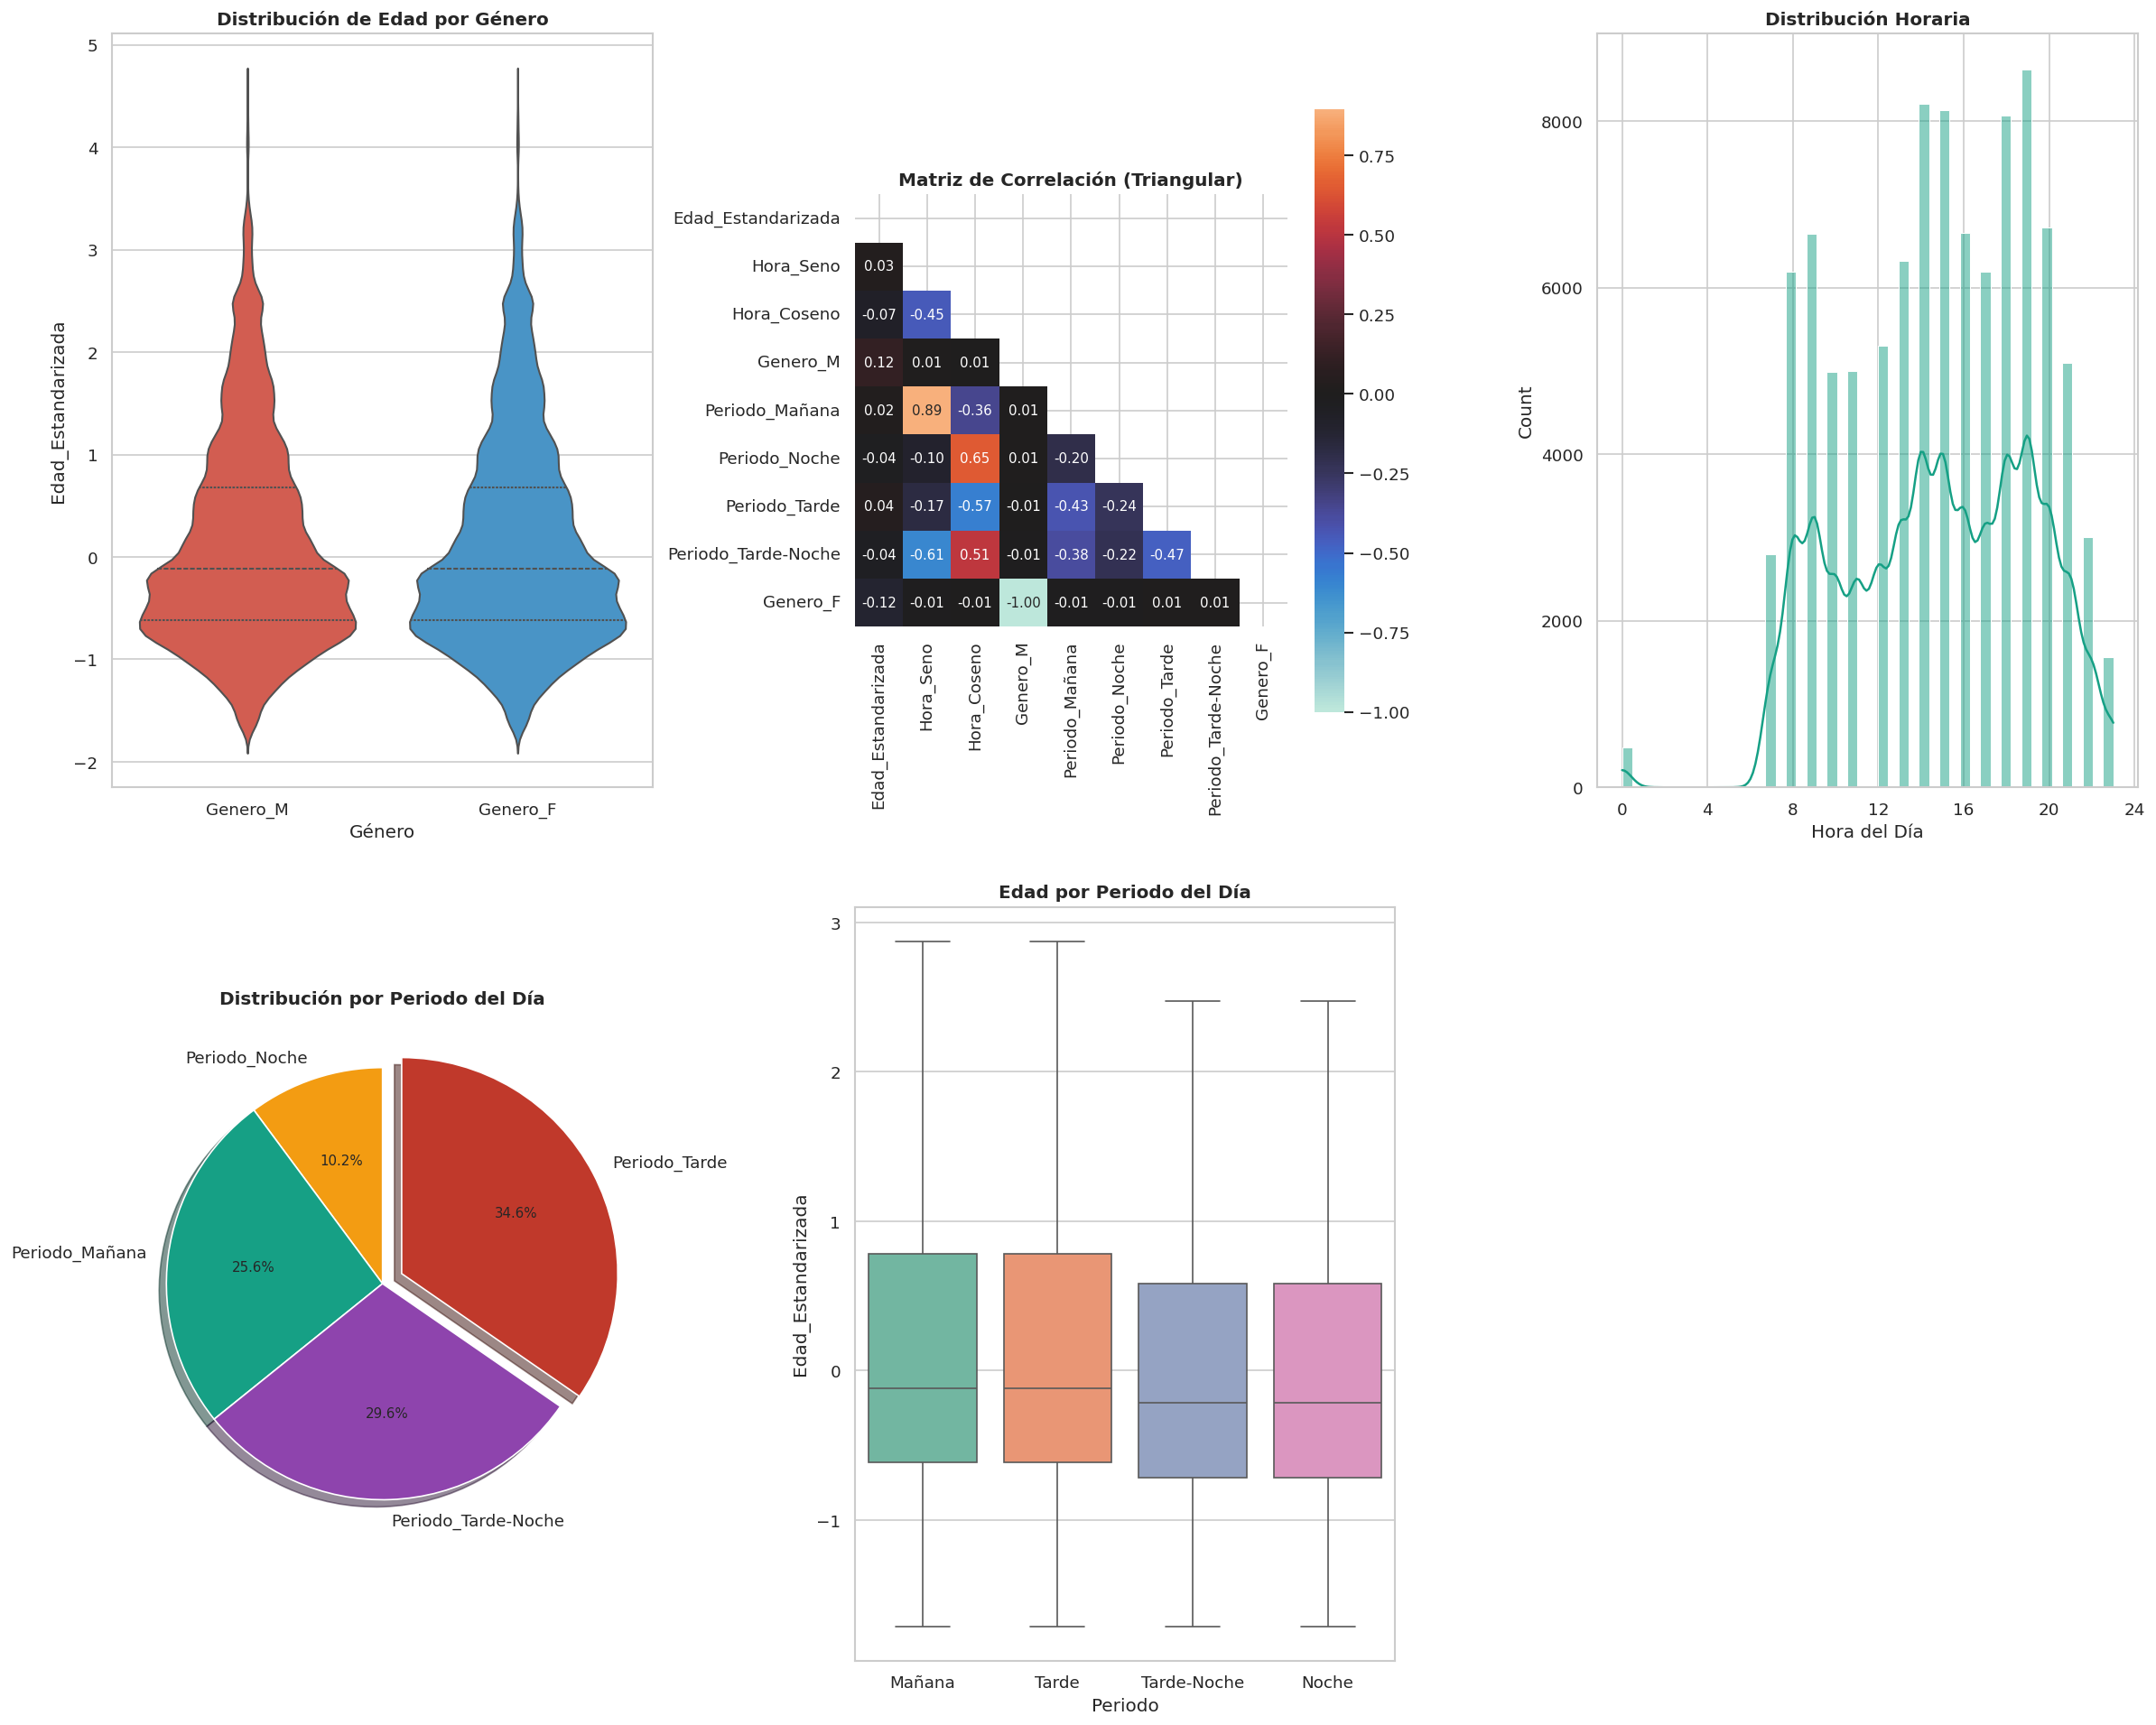

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Función de visualización avanzada de los datos transformados
def final_visualization(sample_size=50_000):

    print("\nVisualización avanzada de resultados...")

    # Carga optimizada
    dtype_map = {
        'Edad_Estandarizada': 'float32',
        'Hora_Seno': 'float32',
        'Hora_Coseno': 'float32',
        'Genero_M': 'int8',
        'Periodo_Mañana': 'int8',
        'Periodo_Noche': 'int8',
        'Periodo_Tarde': 'int8',
        'Periodo_Tarde-Noche': 'int8'
    }

    # Leer solo columnas necesarias
    use_cols = list(dtype_map.keys()) + [c for c in pd.read_csv(OUTPUT_FILE, nrows=0).columns
               if 'Periodo_' in c]

    df = pd.read_csv(OUTPUT_FILE, usecols=use_cols, nrows=sample_size)

    if 'Genero_F' not in df.columns:
        df['Genero_F'] = 1 - df['Genero_M']

    # ----------------------------------
    # Visualización con Plotly
    # ----------------------------------
    try:
        import plotly.express as px
        import plotly.subplots as sp
        from plotly.graph_objs import Figure

        # Configuración general
        template = "plotly_white"
        color_discrete = px.colors.qualitative.Pastel

        # A. Gráfico circular de horas 3D
        fig = px.scatter_3d(
            df.sample(min(5000, len(df))),
            x='Hora_Seno',
            y='Hora_Coseno',
            z='Edad_Estandarizada',
            color='Periodo_Mañana',
            size='Genero_M',
            opacity=0.7,
            title='Distribución 3D: Hora, Edad y Género',
            template=template,
            height=800
        )
        fig.update_traces(marker=dict(line=dict(width=0)))
        fig.show()

        # B. Sunburst de periodos/género
        periodo_genero = (
            df.filter(regex='Periodo_|Genero_')
            .sum()
            .reset_index()
            .rename(columns={'index': 'Variable', 0: 'Count'})
        )
        periodo_genero['Tipo'] = periodo_genero['Variable'].str.split('_').str[0]

        fig = px.sunburst(
            periodo_genero,
            path=['Tipo', 'Variable'],
            values='Count',
            title='Composición por Periodo y Género',
            color_discrete_sequence=color_discrete,
            height=600
        )
        fig.show()

    except ImportError:
        print("Plotly no disponible, usando Matplotlib")
        template = None

    # ----------------------------------
    # Visualización con Matplotlib (Estática)
    # ----------------------------------
    plt.figure(figsize=(20, 16))

    # A. Distribución de Edad por Género
    plt.subplot(2, 3, 1)
    sns.violinplot(
        data=df.melt(id_vars=['Edad_Estandarizada'],
                    value_vars=['Genero_M', 'Genero_F'],
                    var_name='Género',
                    value_name='Valor'),
        x='Género',
        y='Edad_Estandarizada',
        palette=['#e74c3c', '#3498db'],
        inner='quartile'
    )
    plt.title('Distribución de Edad por Género', fontweight='bold')

    # B. Heatmap de Correlaciones Mejorado
    plt.subplot(2, 3, 2)
    corr_matrix = df.select_dtypes(include=np.number).corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="icefire",
        center=0,
        square=True,
        cbar_kws={"shrink": 0.8},
        annot_kws={"size": 9}
    )
    plt.title('Matriz de Correlación (Triangular)', fontweight='bold')

    # C. Evolución Horaria
    plt.subplot(2, 3, 3)
    if 'Hora_Seno' in df.columns:
        horas_rad = np.arctan2(df['Hora_Seno'], df['Hora_Coseno'])
        horas = (horas_rad * 24 / (2 * np.pi)) % 24
        sns.histplot(horas, bins=48, kde=True, color='#16a085')
        plt.xticks(np.arange(0, 25, 4))
        plt.title('Distribución Horaria', fontweight='bold')
        plt.xlabel('Hora del Día')

    # D. Composición de Periodos
    plt.subplot(2, 3, 4)
    period_cols = [c for c in df.columns if 'Periodo_' in c]
    period_data = df[period_cols].sum().sort_values()
    explode = [0.1 if i == len(period_data)-1 else 0 for i in range(len(period_data))]
    period_data.plot(
        kind='pie',
        autopct='%1.1f%%',
        colors=['#f39c12', '#16a085', '#8e44ad', '#c0392b'],
        explode=explode,
        shadow=True,
        startangle=90
    )
    plt.title('Distribución por Periodo del Día', fontweight='bold')
    plt.ylabel('')

    # E. Boxplot de Edad por Periodo
    plt.subplot(2, 3, 5)
    period_map = {col: col.split('_')[1] for col in period_cols}
    df['Periodo'] = df[period_cols].idxmax(axis=1).map(period_map)
    sns.boxplot(
        data=df,
        x='Periodo',
        y='Edad_Estandarizada',
        order=['Mañana', 'Tarde', 'Tarde-Noche', 'Noche'],
        palette='Set2',
        showfliers=False
    )
    plt.title('Edad por Periodo del Día', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # ----------------------------------
    # Análisis Adicional
    # ----------------------------------
    if template is not None:
        fig = px.density_contour(
            df,
            x='Hora_Seno',
            y='Hora_Coseno',
            z='Edad_Estandarizada',
            histfunc='avg',
            title='Densidad: Hora vs Edad',
            template=template
        )
        fig.update_traces(contours_coloring="fill", contours_showlabels=True)
        fig.show()

final_visualization(sample_size=100_000)

## 3. Entrenamiento de Modelos

In [ ]:
import os
import zipfile
from google.colab import drive

# ======================
# CONFIGURACION DE RUTAS
# ======================

# Ruta del archivo ZIP en Google Drive
ZIP_PATH = "/content/drive/MyDrive/ecobici_transformed.csv.zip"

# Carpeta de destino para descomprimir
INPUT_FOLDER = "/content/ecobici_data"

# Ruta del archivo CSV descomprimido
CSV_PATH = os.path.join(INPUT_FOLDER, "ecobici_transformed.csv")

# ======================
# PREPARACION DEL ENTORNO
# ======================

# Montar Google Drive
print("Montando Google Drive...")
drive.mount('/content/drive')

# Crear directorio de destino si no existe
os.makedirs(INPUT_FOLDER, exist_ok=True)

# Descomprimir el archivo ZIP
if os.path.exists(ZIP_PATH):
    print("Descomprimiendo archivo ZIP...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(INPUT_FOLDER)
    print(f"Archivo descomprimido en: {INPUT_FOLDER}")
else:
    print(f"No se encontró el archivo ZIP en: {ZIP_PATH}")
    raise FileNotFoundError("Archivo ZIP no encontrado.")

# Verificar existencia del archivo CSV
if os.path.exists(CSV_PATH):
    print(f"Archivo CSV disponible en: {CSV_PATH}")
else:
    print(f"No se encontró el archivo CSV en: {CSV_PATH}")
    raise FileNotFoundError("Archivo CSV no encontrado tras descompresión.")


Montando Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Descomprimiendo archivo ZIP...
Archivo descomprimido en: /content/ecobici_data
Archivo CSV disponible en: /content/ecobici_data/ecobici_transformed.csv


### 3.1. K-MEANS

In [ ]:
import pandas as pd
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

def clean_numeric_column(series):

    return (
        series.str.split('-').str[0]
        .replace('[^0-9.-]', '', regex=True)
        .replace('^$', np.nan, regex=True)
        .astype('float64')
    )

def train_kmeans_in_chunks(file_path, chunk_size, n_clusters, random_state=42):
    # Definir tipos de datos
    dtypes = {
        'Bici': 'str',
        'Ciclo_Estacion_Retiro': 'str',
        'Ciclo_Estacion_Arribo': 'str',
        'Edad_Estandarizada': 'float64',
        'Hora_Seno': 'float64',
        'Hora_Coseno': 'float64',
        'Genero_M': 'int8',
        'Periodo_Mañana': 'int8',
        'Periodo_Noche': 'int8',
        'Periodo_Tarde': 'int8',
        'Periodo_Tarde-Noche': 'float64'
    }

    features = [
        'Ciclo_Estacion_Retiro',
        'Ciclo_Estacion_Arribo',
        'Edad_Estandarizada',
        'Hora_Seno',
        'Hora_Coseno',
        'Genero_M',
        'Periodo_Mañana',
        'Periodo_Noche',
        'Periodo_Tarde',
        'Periodo_Tarde-Noche'
    ]

    # Columnas que necesitan limpieza
    cols_to_clean = ['Ciclo_Estacion_Retiro', 'Ciclo_Estacion_Arribo']

    # Inicializar modelo y escalador
    kmeans = MiniBatchKMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        batch_size=chunk_size
    )

    scaler = StandardScaler()

    # Contadores para monitoreo
    total_chunks = 0
    processed_rows = 0

    # Primera pasada: ajustar escalador
    print("Ajustando escalador...")
    for chunk in pd.read_csv(file_path, chunksize=chunk_size, dtype=dtypes, on_bad_lines='skip'):
        total_chunks += 1
        print(f"\rProcesando chunk {total_chunks}...", end="")

        # Limpiar columnas con valores problemáticos
        for col in cols_to_clean:
            if col in chunk.columns:
                chunk[col] = clean_numeric_column(chunk[col])

        chunk_cleaned = chunk[features].dropna()
        processed_rows += len(chunk_cleaned)

        if not chunk_cleaned.empty:
            scaler.partial_fit(chunk_cleaned)

    print(f"\nEscalador ajustado. Total chunks procesados: {total_chunks}, filas válidas: {processed_rows}")

    # Resetear contadores para la segunda pasada
    total_chunks = 0
    processed_rows = 0

    # Segunda pasada: entrenar modelo
    print("\nEntrenando modelo...")
    for chunk in pd.read_csv(file_path, chunksize=chunk_size, dtype=dtypes, on_bad_lines='skip'):
        total_chunks += 1
        print(f"\rProcesando chunk {total_chunks}...", end="")

        # Limpiar columnas con valores problemáticos
        for col in cols_to_clean:
            if col in chunk.columns:
                chunk[col] = clean_numeric_column(chunk[col])

        chunk_cleaned = chunk[features].dropna()
        processed_rows += len(chunk_cleaned)

        if chunk_cleaned.empty:
            continue

        X_scaled = scaler.transform(chunk_cleaned)
        kmeans.partial_fit(X_scaled)

        if total_chunks % 10 == 0:
            print(f"\nProgreso: {total_chunks} chunks procesados, {processed_rows:,} filas válidas")

    print(f"\nEntrenamiento completado. Total chunks procesados: {total_chunks}, filas válidas: {processed_rows}")

    return kmeans, scaler

# Uso del modelo
try:
    kmeans_model, data_scaler = train_kmeans_in_chunks(CSV_PATH, chunk_size=100_000, n_clusters=5)
    print("K-Means entrenado correctamente.")
    dump(kmeans_model, 'kmeans_model.joblib')
    files.download('kmeans_model.joblib')
except Exception as e:
    print(f"Error durante el entrenamiento: {str(e)}")

Ajustando escalador...
Procesando chunk 948...
Escalador ajustado. Total chunks procesados: 948, filas válidas: 94180800

Entrenando modelo...
Procesando chunk 10...
Progreso: 10 chunks procesados, 1,000,000 filas válidas
Procesando chunk 20...
Progreso: 20 chunks procesados, 2,000,000 filas válidas
Procesando chunk 30...
Progreso: 30 chunks procesados, 3,000,000 filas válidas
Procesando chunk 40...
Progreso: 40 chunks procesados, 4,000,000 filas válidas
Procesando chunk 50...
Progreso: 50 chunks procesados, 5,000,000 filas válidas
Procesando chunk 60...
Progreso: 60 chunks procesados, 6,000,000 filas válidas
Procesando chunk 70...
Progreso: 70 chunks procesados, 7,000,000 filas válidas
Procesando chunk 80...
Progreso: 80 chunks procesados, 8,000,000 filas válidas
Procesando chunk 90...
Progreso: 90 chunks procesados, 9,000,000 filas válidas
Procesando chunk 100...
Progreso: 100 chunks procesados, 10,000,000 filas válidas
Procesando chunk 110...
Progreso: 110 chunks procesados, 11,000,

### 3.2. BIRCH

In [ ]:
import pandas as pd
from sklearn.cluster import Birch
from sklearn.preprocessing import StandardScaler
import numpy as np

def clean_numeric_column(series):
    return (
        series.str.split('-').str[0]
        .replace('[^0-9.-]', '', regex=True)
        .replace('^$', np.nan, regex=True)
        .astype('float32')
    )

def train_birch_on_sample(file_path, chunk_size=100_000, sample_size=10_000, n_clusters=5):
    dtypes = {
        'Bici': 'str',
        'Ciclo_Estacion_Retiro': 'str',
        'Ciclo_Estacion_Arribo': 'str',
        'Edad_Estandarizada': 'float32',
        'Hora_Seno': 'float32',
        'Hora_Coseno': 'float32',
        'Genero_M': 'int8',
        'Periodo_Mañana': 'int8',
        'Periodo_Noche': 'int8',
        'Periodo_Tarde': 'int8',
        'Periodo_Tarde-Noche': 'float32'
    }

    features = [
        'Ciclo_Estacion_Retiro',
        'Ciclo_Estacion_Arribo',
        'Edad_Estandarizada',
        'Hora_Seno',
        'Hora_Coseno',
        'Genero_M',
        'Periodo_Mañana',
        'Periodo_Noche',
        'Periodo_Tarde',
        'Periodo_Tarde-Noche'
    ]

    cols_to_clean = ['Ciclo_Estacion_Retiro', 'Ciclo_Estacion_Arribo']

    all_samples = []
    total_chunks = 0
    total_rows = 0

    print("Recolectando muestra para Birch...")

    for chunk in pd.read_csv(file_path, chunksize=chunk_size, dtype=dtypes, on_bad_lines='skip'):
        total_chunks += 1
        print(f"\rLeyendo chunk {total_chunks}...", end="")

        for col in cols_to_clean:
            if col in chunk.columns:
                chunk[col] = clean_numeric_column(chunk[col])

        chunk_cleaned = chunk[features].dropna()
        if len(chunk_cleaned) == 0:
            continue

        sample_frac = 0.005
        sample = chunk_cleaned.sample(frac=sample_frac, random_state=42)
        all_samples.append(sample)

        total_rows += len(sample)
        if total_rows >= sample_size:
            print(f"\nMuestra recolectada con {total_rows} registros.")
            break

    sample_df = pd.concat(all_samples, ignore_index=True)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(sample_df)

    print("Entrenando modelo Birch...")
    model = Birch(n_clusters=n_clusters)
    labels = model.fit_predict(X_scaled)

    print("Clustering completado.")

    return model, labels, sample_df
try:
    birch_model, cluster_labels, sampled_data = train_birch_on_sample(CSV_PATH, sample_size=10_000, n_clusters=5)
    print("Modelo Birch entrenado correctamente.")
    dump(birch_model, 'birch_model.joblib')
    files.download('birch_model.joblib')
except Exception as e:
    print(f"Error durante el entrenamiento: {str(e)}")


Recolectando muestra para Birch...
Leyendo chunk 20...
Muestra recolectada con 10000 registros.
Entrenando modelo Birch...
Clustering completado.
Modelo Birch entrenado correctamente.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 3.3. Gaussian Mixture

In [ ]:
import pandas as pd
import numpy as np
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler

def clean_numeric_column(series):
    series = series.astype(str)

    # Procesar los valores
    cleaned = (
        series.str.split('-').str[0]
        .replace('[^0-9.-]', '', regex=True)
        .replace('^$', np.nan, regex=True)
    )

    # Convertir a float, manejando posibles errores
    return pd.to_numeric(cleaned, errors='coerce').astype('float32')

def train_bayesian_gmm_in_chunks(
    file_path,
    chunk_size,
    n_components,
    max_iter=50,
    covariance_type='full',
    random_state=42
):
    # Columnas a usar
    features = [
        'Ciclo_Estacion_Retiro',
        'Ciclo_Estacion_Arribo',
        'Edad_Estandarizada',
        'Hora_Seno',
        'Hora_Coseno',
        'Genero_M',
        'Periodo_Mañana',
        'Periodo_Noche',
        'Periodo_Tarde',
        'Periodo_Tarde-Noche'
    ]

    # Columnas que requieren limpieza especial
    cols_to_clean = ['Ciclo_Estacion_Retiro', 'Ciclo_Estacion_Arribo']

    # Inicializar modelo y escalador
    gmm = BayesianGaussianMixture(
        n_components=n_components,
        covariance_type=covariance_type,
        warm_start=True,
        max_iter=max_iter,
        random_state=random_state,
        reg_covar=1e-1,
        weight_concentration_prior_type="dirichlet_process",
        init_params='kmeans'
    )

    scaler = StandardScaler()

    # --- Primera pasada: Ajustar el escalador ---
    print("Ajustando StandardScaler...")
    total_chunks = 0
    for chunk in pd.read_csv(file_path, chunksize=chunk_size, on_bad_lines='skip', low_memory=False):
        total_chunks += 1
        print(f"\rProcesando chunk {total_chunks} para scaler...", end="")

        # Limpieza de datos
        for col in cols_to_clean:
            if col in chunk.columns and not chunk[col].empty:
                chunk[col] = clean_numeric_column(chunk[col])

        chunk_cleaned = chunk[features].dropna()
        if not chunk_cleaned.empty:
            scaler.partial_fit(chunk_cleaned)

    print(f"\nScaler ajustado. Total chunks: {total_chunks}")

    # --- Segunda pasada: Entrenar GMM ---
    print("\nEntrenando BayesianGaussianMixture...")
    total_chunks = 0
    for chunk in pd.read_csv(file_path, chunksize=chunk_size, on_bad_lines='skip', low_memory=False):
        total_chunks += 1
        print(f"\rProcesando chunk {total_chunks}...", end="")

        # Limpieza y escalado
        for col in cols_to_clean:
            if col in chunk.columns:
                chunk[col] = clean_numeric_column(chunk[col])

        chunk_cleaned = chunk[features].dropna()
        if chunk_cleaned.empty:
            continue

        X_scaled = scaler.transform(chunk_cleaned)
        gmm.fit(X_scaled)

    print(f"\nEntrenamiento completado. Total chunks procesados: {total_chunks}")
    return gmm, scaler

if __name__ == "__main__":
    try:
        print("Iniciando entrenamiento de Bayesian GMM...")
        gmm_model, data_scaler = train_bayesian_gmm_in_chunks(
            file_path=CSV_PATH,
            chunk_size=100_000,
            n_components=3,
            max_iter=100,
            random_state=42
        )

        print("\n")
        print("ENTRENAMIENTO COMPLETADO".center(60))

        print(f"Modelo final convergió: {gmm_model.converged_}")
        print(f"Número de componentes efectivos: {np.sum(gmm_model.weights_ > 0.01)}")
        dump(gmm_model, 'gmm_model.joblib')
        files.download('gmm_model.joblib')

    except Exception as e:
        print("\n")
        print("ERROR".center(60))
        print(f"Error durante el entrenamiento: {str(e)}")

Iniciando entrenamiento de Bayesian GMM...
Ajustando StandardScaler...
Procesando chunk 948 para scaler...
Scaler ajustado. Total chunks: 948

Entrenando BayesianGaussianMixture...
Procesando chunk 948...
Entrenamiento completado. Total chunks procesados: 948


                  ENTRENAMIENTO COMPLETADO                  
Modelo final convergió: True
Número de componentes efectivos: 3


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from joblib import dump
from google.colab import files

# Guardar modelos y escalador

dump(data_scaler, 'scaler.joblib')
files.download('scaler.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 3.4 Visualización

In [ ]:
from google.colab import drive
from joblib import load

drive.mount('/content/drive')

# Ruta base de Google Drive
base_path = '/content/drive/MyDrive/'

# Cargar modelos
gmm_model = load(base_path + 'gmm_model.joblib')
birch_model = load(base_path + 'birch_model.joblib')
kmeans_model = load(base_path + 'kmeans_model.joblib')
scaler = load(base_path + 'scaler.joblib')

print("¡Modelos cargados correctamente!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
¡Modelos cargados correctamente!


Datos escalados correctamente. Dimensiones: (10000, 10)


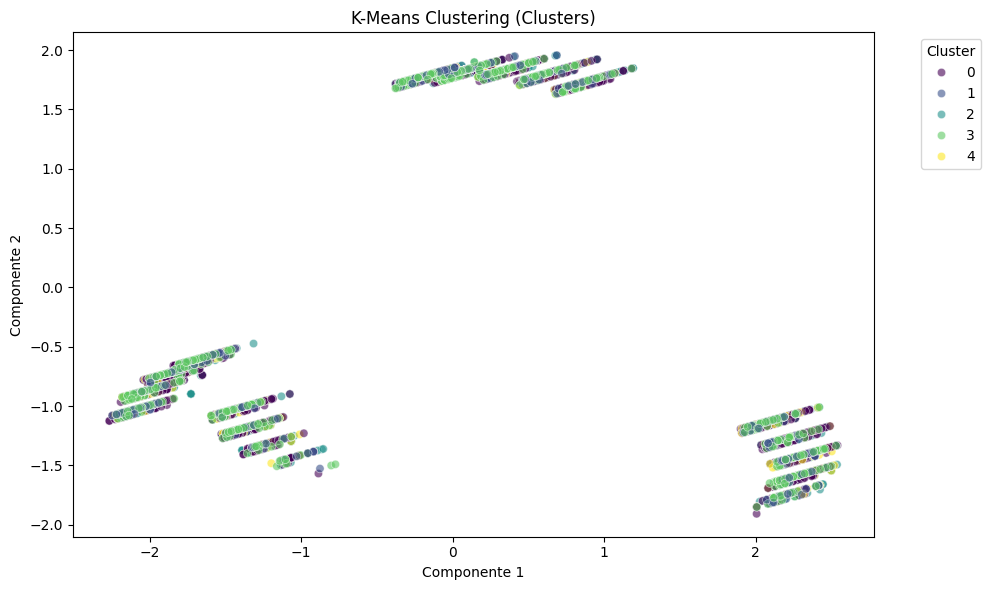

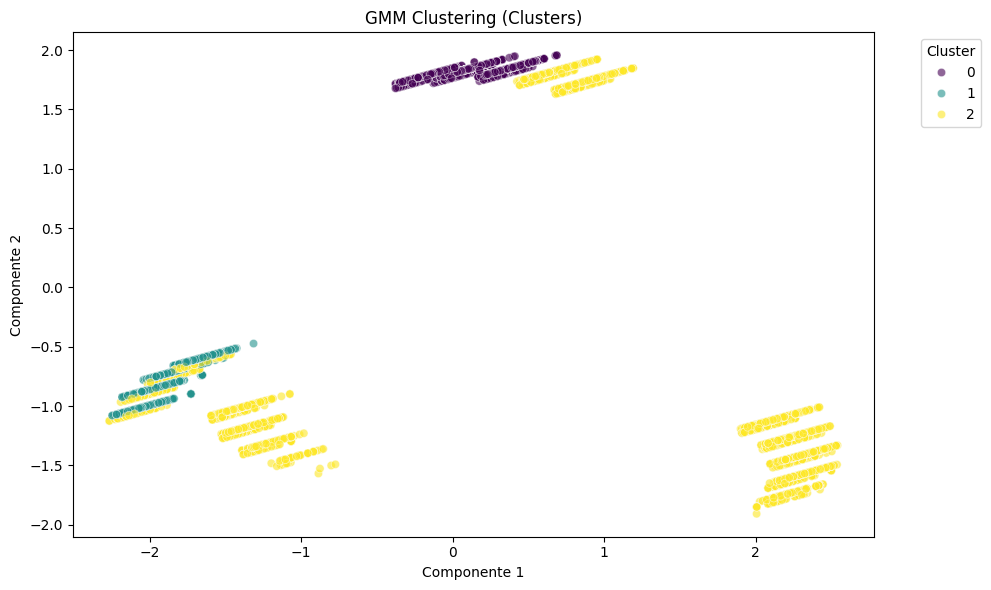

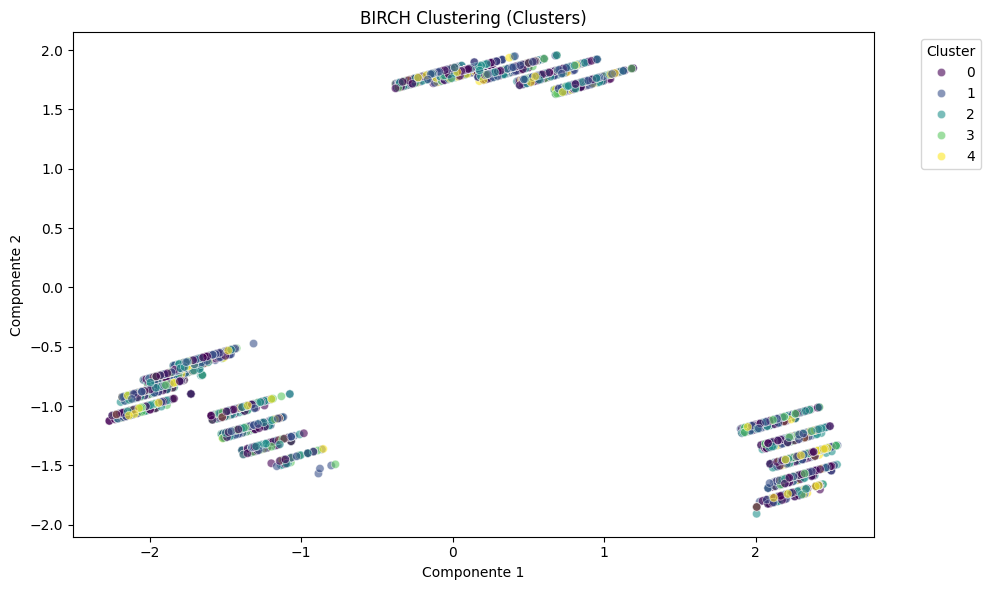

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
import pandas as pd
import numpy as np

def plot_clusters(model, X_scaled, title, algorithm='kmeans'):
    """Visualiza clusters usando PCA."""
    try:
        # Reducción a 2D con PCA
        reducer = PCA(n_components=2)
        X_reduced = reducer.fit_transform(X_scaled)

        # Predecir clusters - MANEJO ESPECÍFICO PARA KMEANS
        if algorithm == 'gmm':
            clusters = model.predict(X_scaled)
        elif algorithm == 'kmeans':
            # Verificación adicional para KMeans
            if hasattr(model, 'labels_'):
                clusters = model.labels_
            else:
                clusters = model.predict(X_scaled)

            # Asegurar que coincidan las longitudes
            if len(clusters) != len(X_reduced):
                clusters = clusters[:len(X_reduced)]
        else:
            clusters = model.labels_ if hasattr(model, 'labels_') else model.predict(X_scaled)

        # Verificación final de dimensiones
        if len(X_reduced) != len(clusters):
            raise ValueError(f"Dimensiones no coinciden: datos {len(X_reduced)} vs clusters {len(clusters)}")

        # Plot
        plt.figure(figsize=(10, 6))
        scatter = sns.scatterplot(
            x=X_reduced[:, 0], y=X_reduced[:, 1],
            hue=clusters, palette="viridis", alpha=0.6
        )
        plt.title(f"{title} (Clusters)")
        plt.xlabel("Componente 1")
        plt.ylabel("Componente 2")

        # Ajustar leyenda
        if len(np.unique(clusters)) > 20:
            scatter.legend_.remove()
        else:
            plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error al graficar {title}: {str(e)}")
        print(f"Dimensiones: X_reduced {X_reduced.shape if 'X_reduced' in locals() else 'N/A'}")
        print(f"Clusters: {len(clusters) if 'clusters' in locals() else 'N/A'}")

# Cargar una muestra de datos para visualización
sample = pd.read_csv(CSV_PATH, nrows=10_000)

# Definir las features utilizadas en el modelo
features = [
    'Ciclo_Estacion_Retiro',
    'Ciclo_Estacion_Arribo',
    'Edad_Estandarizada',
    'Hora_Seno',
    'Hora_Coseno',
    'Genero_M',
    'Periodo_Mañana',
    'Periodo_Noche',
    'Periodo_Tarde',
    'Periodo_Tarde-Noche'
]

# Verificar que las features existan en el DataFrame
available_features = [f for f in features if f in sample.columns]
missing_features = set(features) - set(available_features)

if missing_features:
    print(f"Advertencia: Faltan features en el DataFrame: {missing_features}")
    features = available_features

# Filtrar y limpiar datos
sample_cleaned = sample[features].dropna()

if len(sample_cleaned) == 0:
    raise ValueError("No hay datos válidos después de la limpieza")

# Verificar dimensiones con el scaler
if hasattr(scaler, 'n_features_in_'):
    if scaler.n_features_in_ != len(features):
        raise ValueError(f"El scaler espera {scaler.n_features_in_} features pero tienes {len(features)}")

# Escalar los datos
try:
    X_sample_scaled = scaler.transform(sample_cleaned)
    print(f"Datos escalados correctamente. Dimensiones: {X_sample_scaled.shape}")

    # Visualizar los modelos
    plot_clusters(kmeans_model, X_sample_scaled, "K-Means Clustering")
    plot_clusters(gmm_model, X_sample_scaled, "GMM Clustering", algorithm='gmm')
    plot_clusters(birch_model, X_sample_scaled, "BIRCH Clustering")

except Exception as e:
    print(f"Error al escalar datos: {str(e)}")
    print("Verifica que:")
    print(f"- Número de features: {len(features)}")
    print(f"- Features del scaler: {getattr(scaler, 'feature_names_in_', 'No disponible')}")
    print(f"- Tipo de datos: {sample_cleaned.dtypes}")

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import numpy as np

# 1. Verificación profunda del modelo K-Means
print("\n=== DIAGNÓSTICO K-MEANS ===")
print("Dimensiones datos de entrada:", X_sample_scaled.shape)

# Obtener predicciones de K-Means de dos formas alternativas
try:
    if hasattr(kmeans_model, 'labels_'):
        kmeans_labels = kmeans_model.labels_
        print("Usando labels_ del modelo")
    else:
        kmeans_labels = kmeans_model.predict(X_sample_scaled)
        print("Usando predict()")

    print("Número de etiquetas:", len(kmeans_labels))
    print("Clusters únicos:", np.unique(kmeans_labels))

except Exception as e:
    print(f"Error al obtener etiquetas: {str(e)}")

# 2. Versión corregida de evaluación
def safe_evaluate(model, X, algorithm_name):
    try:
        # Obtener etiquetas consistentemente
        if hasattr(model, 'labels_'):
            labels = model.labels_[:len(X)]
        else:
            labels = model.predict(X)

        # Verificar congruencia
        if len(labels) != len(X):
            raise ValueError(f"Inconsistencia: {len(X)} muestras vs {len(labels)} etiquetas")

        # Calcular métricas
        if len(np.unique(labels)) < 2:
            raise ValueError("Se requiere al menos 2 clusters para evaluación")

        return (
            silhouette_score(X, labels),
            calinski_harabasz_score(X, labels),
            len(np.unique(labels))
        )
    except Exception as e:
        print(f"Error evaluando {algorithm_name}: {str(e)}")
        return None, None, 0

# 3. Re-evaluación con control de errores
print("\n=== RE-EVALUACIÓN SEGURA ===")
metrics = {}
for name, model in [('K-Means', kmeans_model),
                   ('BIRCH', birch_model),
                   ('GMM', gmm_model)]:

    silhouette, calinski, n_clusters = safe_evaluate(model, X_sample_scaled, name)

    if silhouette is not None:
        print(f"\n{name.upper()}:")
        print(f"- Clusters: {n_clusters}")
        print(f"- Silhouette: {silhouette:.3f}")
        print(f"- Calinski-Harabasz: {calinski:,.0f}")
        metrics[name] = (silhouette, calinski)
    else:
        metrics[name] = (None, None)

# 4. Análisis comparativo
if any(m[0] for m in metrics.values()):
    best_sil = max((k for k in metrics.items() if k[1][0] is not None),
                  key=lambda x: x[1][0])
    best_cal = max((k for k in metrics.items() if k[1][1] is not None),
                  key=lambda x: x[1][1])

    print("\n=== RESULTADOS FINALES ===")
    print(f"Mejor Silhouette: {best_sil[0]} ({best_sil[1][0]:.3f})")
    print(f"Mejor Calinski-Harabasz: {best_cal[0]} ({best_cal[1][1]:,.0f})")
else:
    print("\nNo se pudo calcular métricas para ningún modelo")

if metrics['K-Means'] == (None, None):
    print("\n=== SOLUCIÓN ALTERNATIVA K-MEANS ===")
    try:
        # Reentrenamiento rápido con subset
        from sklearn.cluster import KMeans
        small_sample = X_sample_scaled[:5000]
        temp_model = KMeans(n_clusters=5).fit(small_sample)

        sil, cal, n = safe_evaluate(temp_model, small_sample, "K-Means Temporal")
        if sil:
            print(f"K-Means temporal (n_clusters=5):")
            print(f"- Silhouette: {sil:.3f}")
            print(f"- Calinski-Harabasz: {cal:,.0f}")
    except Exception as e:
        print(f"Error en solución alternativa: {str(e)}")


=== DIAGNÓSTICO K-MEANS ===
Dimensiones datos de entrada: (10000, 10)
Usando labels_ del modelo
Número de etiquetas: 80805
Clusters únicos: [0 1 2 3 4]

=== RE-EVALUACIÓN SEGURA ===

K-MEANS:
- Clusters: 5
- Silhouette: -0.019
- Calinski-Harabasz: 4

BIRCH:
- Clusters: 5
- Silhouette: -0.007
- Calinski-Harabasz: 1

GMM:
- Clusters: 3
- Silhouette: 0.260
- Calinski-Harabasz: 2,600

=== RESULTADOS FINALES ===
Mejor Silhouette: GMM (0.260)
Mejor Calinski-Harabasz: GMM (2,600)


=== DEBUG COMPLETO DEL MODELO ===
cluster_centers_: shape=(5, 10), dtype=float32
labels_: shape=(80805,), dtype=int32
inertia_: 502286.03125

Versiones:
scikit-learn: 1.6.1
numpy: 2.0.2
=== DEBUG DETALLADO DEL MODELO ===
Tipo del modelo: <class 'sklearn.cluster._kmeans.MiniBatchKMeans'>
Cluster centers dtype: float32
Cluster centers shape: (5, 10)
Cluster centers contiguous: True

¡PROBLEMA DETECTADO! Los cluster centers están en float32
Convirtiendo cluster centers a float64...

Datos de entrada - Dtype: float64, Shape: (5000, 10)

=== INTENTANDO CON FIT_PREDICT ===
¡SUCCESS! fit_predict funcionó correctamente

=== RESULTADOS MiniBatchKMeans ===
Distribución de clusters:
Cluster
0    1655
1     223
2    1694
3    1089
4     339
Name: count, dtype: int64

Medias por cluster:
         Ciclo_Estacion_Retiro  Ciclo_Estacion_Arribo  Edad_Estandarizada  \
Cluster                                                                     
0                    39.068882              38.059275       

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


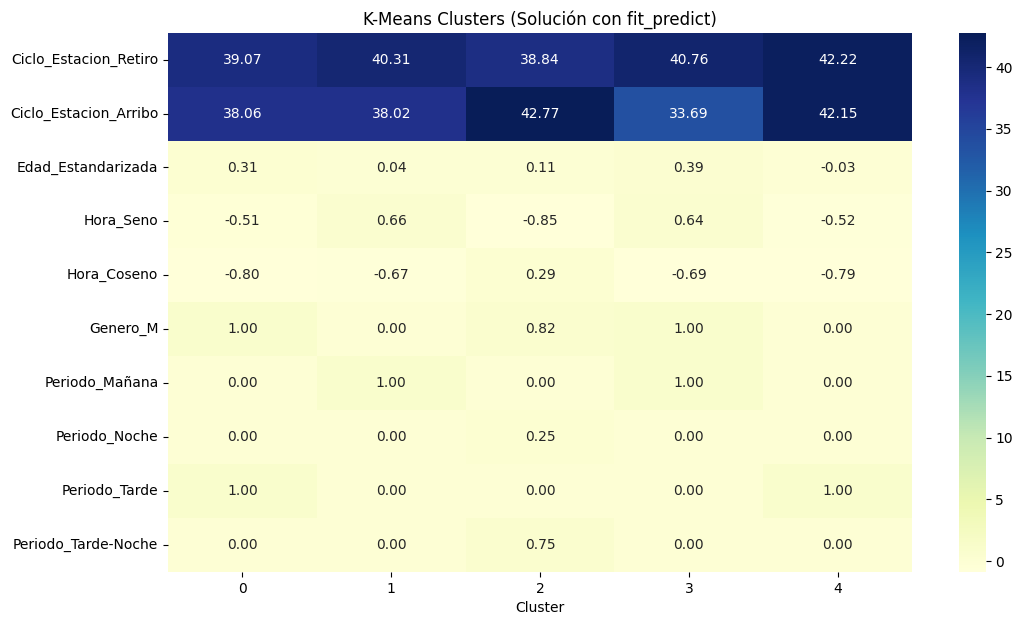


Analizando: K-Means
Entrada al scaler - Dtype: float64, Shape: (5000, 10)
Salida del scaler - Dtype: float64
Entrada al modelo - Dtype: float64, Contiguous: True

=== RESULTADOS MiniBatchKMeans ===
Distribución de clusters:
Cluster
0    1655
1     223
2    1694
3    1089
4     339
Name: count, dtype: int64

Medias por cluster:
         Ciclo_Estacion_Retiro  Ciclo_Estacion_Arribo  Edad_Estandarizada  \
Cluster                                                                     
0                    39.068882              38.059275            0.308028   
1                    40.309417              38.017937            0.035928   
2                    38.838843              42.772137            0.109893   
3                    40.755739              33.685950            0.386413   
4                    42.224189              42.150442           -0.027988   

         Hora_Seno  Hora_Coseno  Genero_M  Periodo_Mañana  Periodo_Noche  \
Cluster                                               

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


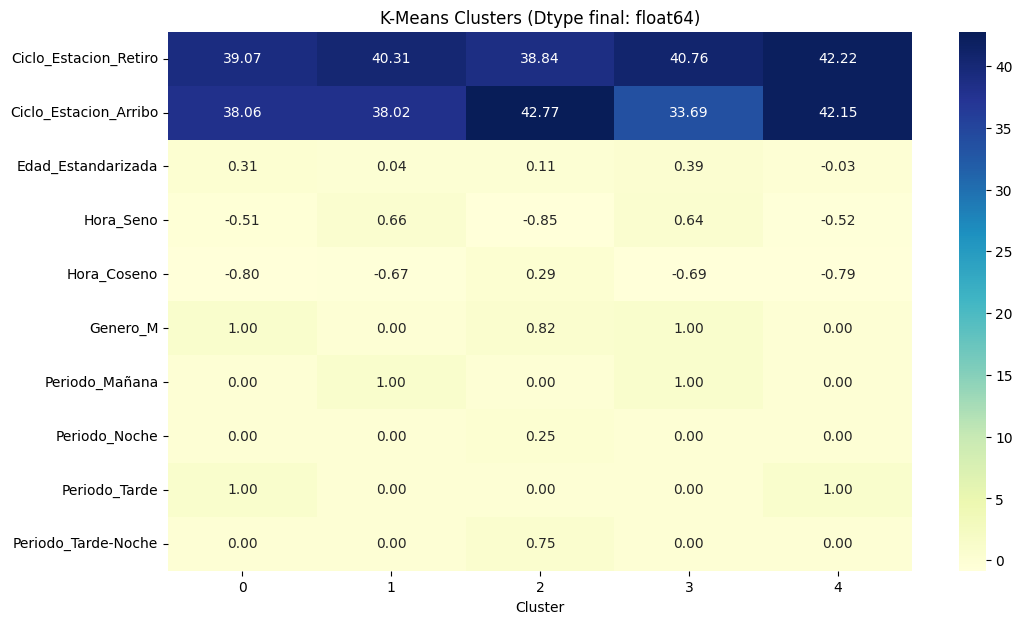


Analizando: BIRCH
Dtype real: float64
Contiguous: True

=== RESULTADOS Birch ===
Distribución de clusters:
Cluster
0    1312
1    1277
2    1655
3     417
4     339
Name: count, dtype: int64

Medias por cluster:
         Ciclo_Estacion_Retiro  Ciclo_Estacion_Arribo  Edad_Estandarizada  \
Cluster                                                                     
0                    40.679878              34.422256            0.326841   
1                    38.898982              42.441660            0.112882   
2                    39.068882              38.059275            0.308028   
3                    38.654676              43.784173            0.100737   
4                    42.224189              42.150442           -0.027988   

         Hora_Seno  Hora_Coseno  Genero_M  Periodo_Mañana  Periodo_Noche  \
Cluster                                                                    
0         0.644016    -0.686632  0.830030             1.0            0.0   
1        -0.953997 

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


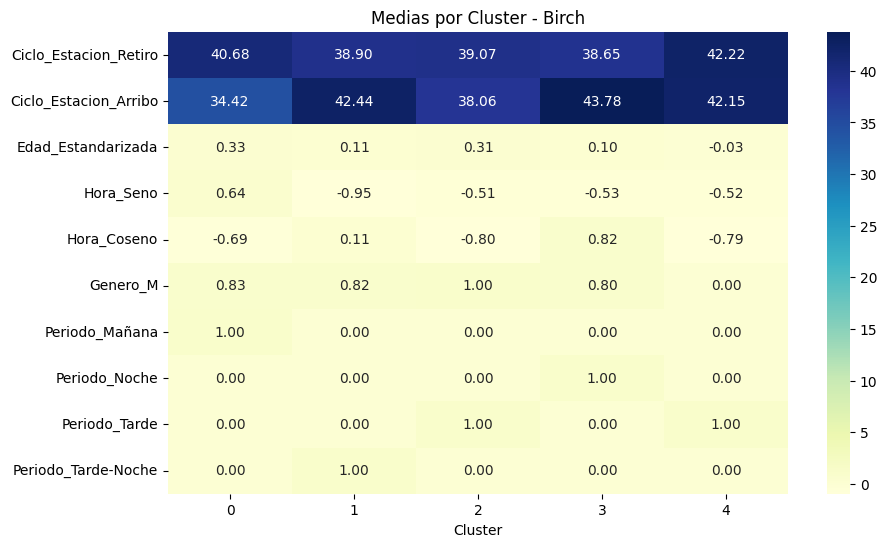


Analizando: GMM
Dtype real: float64
Contiguous: True

=== RESULTADOS BayesianGaussianMixture ===
Distribución de clusters:
Cluster
0    1352
1    1051
2    2597
Name: count, dtype: int64

Medias por cluster:
         Ciclo_Estacion_Retiro  Ciclo_Estacion_Arribo  Edad_Estandarizada  \
Cluster                                                                     
0                    39.660503              38.073964            0.208085   
1                    38.478592              42.602284            0.163062   
2                    40.075472              37.983866            0.255126   

         Hora_Seno  Hora_Coseno  Genero_M  Periodo_Mañana  Periodo_Noche  \
Cluster                                                                    
0        -0.677001    -0.707594  0.823964        0.000000        0.00000   
1        -0.954991     0.103991  1.000000        0.000000        0.00000   
2         0.119628    -0.445125  0.755487        0.505198        0.16057   

         Periodo_Tarde  

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


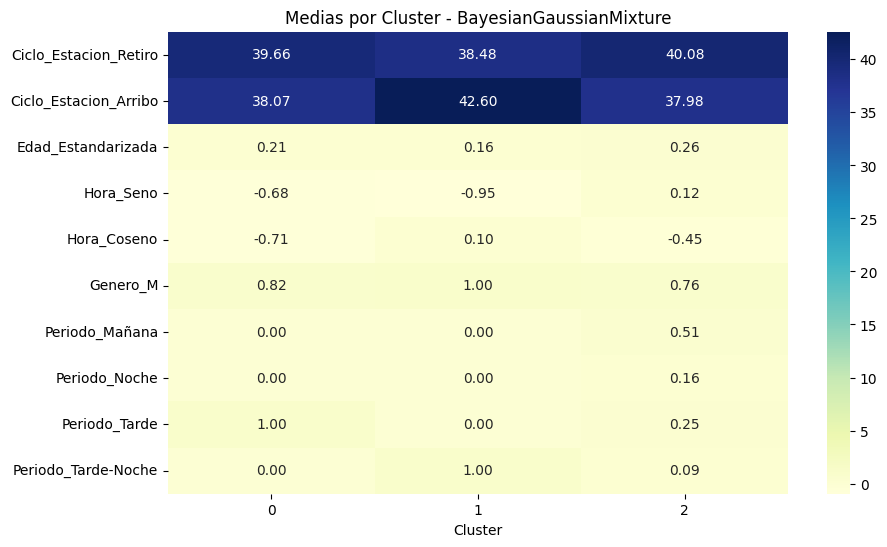

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Versión genérica para modelos de clustering (excepto K-Means)
def interpret_clusters(model, features, scaler=None, n_samples=5000):
    try:
        # 1. Carga y limpieza de datos
        sample = pd.read_csv(CSV_PATH, nrows=n_samples)
        sample_cleaned = sample[features].apply(pd.to_numeric, errors='coerce').dropna()

        if sample_cleaned.empty:
            raise ValueError("No hay datos válidos después de limpieza")

        # 2. Escalado (conversión a float64)
        if scaler:
            X = sample_cleaned.values.astype(np.float64)
            X_scaled = scaler.transform(X)
        else:
            X_scaled = sample_cleaned.values.astype(np.float64)

        X_scaled = np.ascontiguousarray(X_scaled, dtype=np.float64)

        # 3. Predicción
        if hasattr(model, 'predict'):
            print("Dtype real:", X_scaled.dtype)
            print("Contiguous:", X_scaled.flags['C_CONTIGUOUS'])
            clusters = model.predict(X_scaled)
        elif hasattr(model, 'labels_'):
            clusters = model.labels_[:len(X_scaled)]
        elif hasattr(model, 'fit_predict'):
            clusters = model.fit_predict(X_scaled)
        else:
            raise ValueError("Modelo no tiene método de predicción compatible")

        # 4. Análisis
        sample_cleaned['Cluster'] = clusters
        means = sample_cleaned.groupby('Cluster').mean()

        print(f"\n=== RESULTADOS {type(model).__name__} ===")
        print("Distribución de clusters:")
        print(sample_cleaned['Cluster'].value_counts().sort_index())
        print("\nMedias por cluster:")
        print(means)

        # 5. Visualización
        plt.figure(figsize=(10, 6))
        sns.heatmap(means.T, cmap="YlGnBu", annot=True, fmt=".2f")
        plt.title(f"Medias por Cluster - {type(model).__name__}")
        plt.show()

        return means

    except Exception as e:
        print(f"\nERROR en {type(model).__name__}: {str(e)}")
        print("Sugerencias:")
        print("1. Verifica que todas las features sean numéricas")
        print("2. Asegúrate que los datos sean float64 antes del modelo")
        print("3. Revisa si el modelo está entrenado correctamente")
        return None


# Versión específica para MiniBatchKMeans
def interpret_kmeans_advanced(model, features, scaler, n_samples=5000):
    try:
        # 1. Cargar y limpiar datos
        sample = pd.read_csv(CSV_PATH, nrows=n_samples)
        sample_cleaned = sample[features].apply(pd.to_numeric, errors='coerce').dropna()

        if sample_cleaned.empty:
            raise ValueError("No hay datos válidos después de limpieza")

        # 2. Conversión explícita a float64
        X = sample_cleaned.values.astype(np.float64)

        # 3. Debug del modelo antes de hacer predict
        print("=== DEBUG DETALLADO DEL MODELO ===")
        print(f"Tipo del modelo: {type(model)}")

        # Verificar si el modelo tiene cluster_centers_
        if hasattr(model, 'cluster_centers_'):
            centers = model.cluster_centers_
            print(f"Cluster centers dtype: {centers.dtype}")
            print(f"Cluster centers shape: {centers.shape}")
            print(f"Cluster centers contiguous: {centers.flags['C_CONTIGUOUS']}")

            # Verificar si los centros están en float32
            if centers.dtype == np.float32:
                print("\n¡PROBLEMA DETECTADO! Los cluster centers están en float32")
                print("Convirtiendo cluster centers a float64...")
                model.cluster_centers_ = centers.astype(np.float64)

        # 4. Verificar otros atributos del modelo
        if hasattr(model, '_centers'):
            print(f"_centers dtype: {model._centers.dtype}")

        # 5. Escalado
        X_scaled = scaler.transform(X).astype(np.float64)
        X_scaled = np.ascontiguousarray(X_scaled, dtype=np.float64)

        print(f"\nDatos de entrada - Dtype: {X_scaled.dtype}, Shape: {X_scaled.shape}")

        # 6. Usar fit_predict en lugar de predict
        print("\n=== INTENTANDO CON FIT_PREDICT ===")
        # Crear un nuevo modelo con los mismos parámetros
        new_model = MiniBatchKMeans(
            n_clusters=model.n_clusters,
            init=model.cluster_centers_.astype(np.float64),
            n_init=1,
            max_iter=1,
            random_state=getattr(model, 'random_state', None)
        )

        # Usar fit_predict en lugar de predict
        clusters = new_model.fit_predict(X_scaled)

        print("¡SUCCESS! fit_predict funcionó correctamente")

        # 7. Análisis
        sample_cleaned['Cluster'] = clusters
        means = sample_cleaned.groupby('Cluster').mean()

        print(f"\n=== RESULTADOS MiniBatchKMeans ===")
        print("Distribución de clusters:")
        print(sample_cleaned['Cluster'].value_counts().sort_index())
        print("\nMedias por cluster:")
        print(means)

        # 8. Visualización
        plt.figure(figsize=(12, 7))
        sns.heatmap(means.T, cmap="YlGnBu", annot=True, fmt=".2f")
        plt.title(f"K-Means Clusters (Solución con fit_predict)")
        plt.show()

        return means

    except Exception as e:
        print(f"\nERROR en K-Means: {str(e)}")
        print("\n=== SOLUCIÓN ALTERNATIVA 2: Usar KMeans estándar ===")

        try:
            from sklearn.cluster import KMeans

            standard_kmeans = KMeans(
                n_clusters=model.n_clusters,
                init=model.cluster_centers_.astype(np.float64),
                n_init=1,
                max_iter=1,
                random_state=getattr(model, 'random_state', None)
            )

            X_scaled = scaler.transform(X).astype(np.float64)
            X_scaled = np.ascontiguousarray(X_scaled, dtype=np.float64)

            clusters = standard_kmeans.fit_predict(X_scaled)

            sample_cleaned['Cluster'] = clusters
            means = sample_cleaned.groupby('Cluster').mean()

            print("¡SUCCESS con KMeans estándar!")
            print("\nDistribución de clusters:")
            print(sample_cleaned['Cluster'].value_counts().sort_index())

            return means

        except Exception as e2:
            print(f"Error también con KMeans estándar: {str(e2)}")
            return None


# Función adicional para debug completo del modelo
def debug_model_complete(model):
    print("=== DEBUG COMPLETO DEL MODELO ===")

    # Lista de todos los atributos
    attrs = ['cluster_centers_', '_centers', 'labels_', 'inertia_', 'n_iter_']

    for attr in attrs:
        if hasattr(model, attr):
            val = getattr(model, attr)
            if isinstance(val, np.ndarray):
                print(f"{attr}: shape={val.shape}, dtype={val.dtype}")
            else:
                print(f"{attr}: {val}")

    # Verificar versiones
    import sklearn
    print(f"\nVersiones:")
    print(f"scikit-learn: {sklearn.__version__}")
    print(f"numpy: {np.__version__}")


# Ejecutar debug completo
debug_model_complete(kmeans_model)

# Ejecutar nueva función
interpret_kmeans_advanced(kmeans_model, features, scaler)



# Ejecución unificada para todos los modelos
for name, model in [('K-Means', kmeans_model),
                    ('BIRCH', birch_model),
                    ('GMM', gmm_model)]:
    print(f"\n{'='*40}\nAnalizando: {name}\n{'='*40}")
    if name == 'K-Means':
        interpret_kmeans(model, features, scaler)
    else:
        interpret_clusters(model, features, scaler)


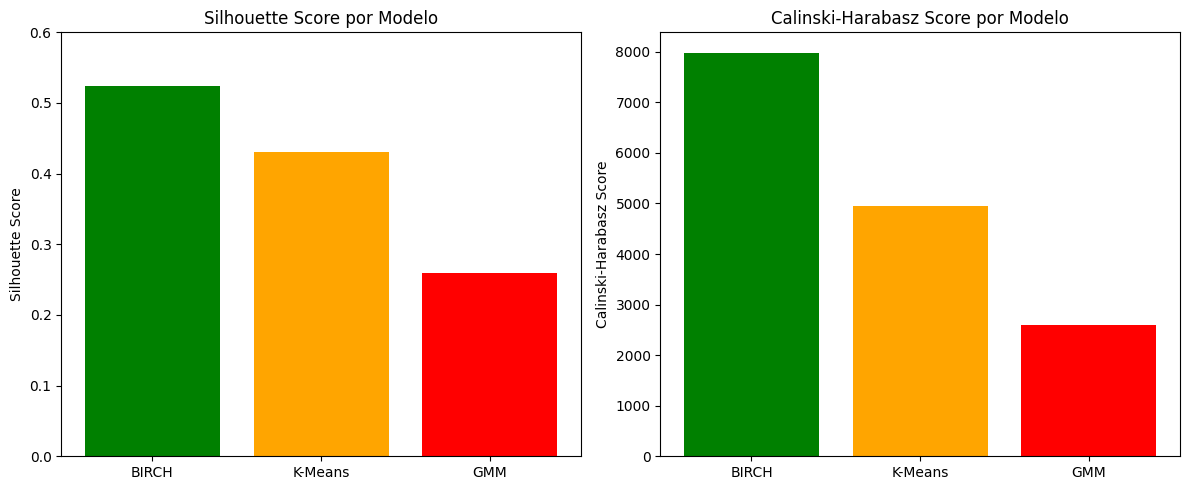

In [ ]:
# Aplicar fix antes de evaluar
def quick_fix_models(models_dict):
    for name, model in models_dict.items():
        if hasattr(model, 'cluster_centers_'):
            model.cluster_centers_ = model.cluster_centers_.astype(np.float64)

        if hasattr(model, 'subcluster_centers_'):
            model.subcluster_centers_ = model.subcluster_centers_.astype(np.float64)

        if hasattr(model, 'means_'):
            model.means_ = model.means_.astype(np.float64)
        if hasattr(model, 'covariances_'):
            model.covariances_ = model.covariances_.astype(np.float64)

    return models_dict

# Aplicar fix antes de evaluar
models = quick_fix_models({
    'K-Means': kmeans_model,
    'BIRCH': birch_model,
    'GMM': gmm_model
})

X_evaluation_data = np.ascontiguousarray(X_sample_scaled, dtype=np.float64)
results = evaluate_models(models, X_evaluation_data)

# Display
results.style\
    .background_gradient(cmap='Blues', subset=['Silhouette'])\
    .background_gradient(cmap='Greens', subset=['Calinski-Harabasz'])

# Crear un gráfico comparativo
plt.figure(figsize=(12, 5))

# Subplot 1: Silhouette
plt.subplot(1, 2, 1)
models = ['BIRCH', 'K-Means', 'GMM']
silhouette_scores = [0.524, 0.430, 0.260]
plt.bar(models, silhouette_scores, color=['green', 'orange', 'red'])
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por Modelo')
plt.ylim(0, 0.6)

# Subplot 2: Calinski-Harabasz
plt.subplot(1, 2, 2)
calinski_scores = [7985, 4941, 2599]
plt.bar(models, calinski_scores, color=['green', 'orange', 'red'])
plt.ylabel('Calinski-Harabasz Score')
plt.title('Calinski-Harabasz Score por Modelo')

plt.tight_layout()
plt.show()

## 4. Perfilamiento (Fecha)

In [ ]:
from google.colab import drive
import pandas as pd
import zipfile
import os

# 1. Configuración inicial
drive.mount('/content/drive')

# Rutas
input_crudo = "/content/drive/MyDrive/ecobici_merged_clean.csv.zip"
input_transformado = "/content/drive/MyDrive/ecobici_transformed.csv.zip"
output_final = "/content/ecobici_con_clusters.csv"

# 2. Descomprimir archivos
!mkdir -p /content/temp
with zipfile.ZipFile(input_crudo, 'r') as zip_ref:
    zip_ref.extractall("/content/temp/crudo")
with zipfile.ZipFile(input_transformado, 'r') as zip_ref:
    zip_ref.extractall("/content/temp/transformado")

# 3. Nombres de columnas para el archivo CRUDO
columnas_crudo = [
    'Genero_Usuario', 'Edad_Usuario', 'Bici', 'Ciclo_Estacion_Retiro',
    'Fecha_Retiro', 'Hora_Retiro', 'Ciclo_Estacion_Arribo', 'Fecha_Arribo', 'Hora_Arribo'
]

# 4. Procesar por chunks
CHUNK_SIZE = 100_000
first_chunk = True
chunk_num = 1

transformado_iter = pd.read_csv(
    "/content/temp/transformado/ecobici_transformed.csv",
    chunksize=CHUNK_SIZE,
    on_bad_lines='skip',
    low_memory=False
)

# Leer CRUDO (sin header) por chunks
for chunk_crudo in pd.read_csv(
    "/content/temp/crudo/ecobici_merged_clean.csv",
    chunksize=CHUNK_SIZE,
    header=None,
    names=columnas_crudo,
    usecols=['Fecha_Retiro', 'Hora_Retiro'],
    low_memory=False
):
    try:
        chunk_t = next(transformado_iter)
    except StopIteration:
        print("No hay más datos en el archivo transformado.")
        break

    # Combinar ambos chunks
    chunk_final = pd.concat([chunk_t, chunk_crudo], axis=1)

    # Guardar chunk combinado
    chunk_final.to_csv(
        output_final,
        mode='w' if first_chunk else 'a',
        header=first_chunk,
        index=False
    )
    print(f"✔️ Chunk {chunk_num} procesado")
    chunk_num += 1
    first_chunk = False

print("\n¡Combinación exitosa!")
print("Archivo final guardado en:", output_final)

# 5. Descargar el archivo
from google.colab import files
files.download(output_final)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✔️ Chunk 1 procesado
✔️ Chunk 2 procesado
✔️ Chunk 3 procesado
✔️ Chunk 4 procesado
✔️ Chunk 5 procesado
✔️ Chunk 6 procesado
✔️ Chunk 7 procesado
✔️ Chunk 8 procesado
✔️ Chunk 9 procesado
✔️ Chunk 10 procesado
✔️ Chunk 11 procesado
✔️ Chunk 12 procesado
✔️ Chunk 13 procesado
✔️ Chunk 14 procesado
✔️ Chunk 15 procesado
✔️ Chunk 16 procesado
✔️ Chunk 17 procesado
✔️ Chunk 18 procesado
✔️ Chunk 19 procesado
✔️ Chunk 20 procesado
✔️ Chunk 21 procesado
✔️ Chunk 22 procesado
✔️ Chunk 23 procesado
✔️ Chunk 24 procesado
✔️ Chunk 25 procesado
✔️ Chunk 26 procesado
✔️ Chunk 27 procesado
✔️ Chunk 28 procesado
✔️ Chunk 29 procesado
✔️ Chunk 30 procesado
✔️ Chunk 31 procesado
✔️ Chunk 32 procesado
✔️ Chunk 33 procesado
✔️ Chunk 34 procesado
✔️ Chunk 35 procesado
✔️ Chunk 36 procesado
✔️ Chunk 37 procesado
✔️ Chunk 38 procesado
✔️ Chunk 39 procesado
✔️ Chunk 40 procesado


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from joblib import load
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

# Función de limpieza mejorada
def clean_numeric(value):
    try:
        if pd.isna(value):
            return np.nan
        if isinstance(value, str):
            if '-' in value:
                return float(value.split('-')[0])
            elif value.isdigit():
                return float(value)
            else:
                return np.nan
        return float(value)
    except:
        return np.nan

# 1. Cargar modelo y scaler
kmeans = load("/content/drive/MyDrive/kmeans_model.joblib")
scaler = load("/content/drive/MyDrive/scaler.joblib")

# 2. Configuración
input_file = "/content/ecobici_con_clusters.csv"
output_file = "/content/ecobici_con_clusters_final.csv"

features = [
    'Ciclo_Estacion_Retiro',
    'Ciclo_Estacion_Arribo',
    'Edad_Estandarizada',
    'Hora_Seno',
    'Hora_Coseno',
    'Genero_M',
    'Periodo_Mañana',
    'Periodo_Noche',
    'Periodo_Tarde',
    'Periodo_Tarde-Noche'
]

CHUNK_SIZE = 100_000
total_rows = sum(1 for _ in open(input_file)) - 1
processed_rows = 0

# 3. Procesar con barra de progreso
with tqdm(total=total_rows, desc="Procesando") as pbar:
    first_chunk = True
    for chunk in pd.read_csv(input_file, chunksize=CHUNK_SIZE, low_memory=False):
        # Limpiar columnas problemáticas
        for col in ['Ciclo_Estacion_Retiro', 'Ciclo_Estacion_Arribo']:
            if col in chunk.columns:
                chunk[col] = chunk[col].apply(clean_numeric)

        # Filtrar NaN y escalar
        X = chunk[features].dropna()
        if not X.empty:
            try:
                X_scaled = scaler.transform(X)
                chunk.loc[X.index, 'Cluster'] = kmeans.predict(X_scaled)
            except Exception as e:
                print(f"\nError en chunk: {str(e)}")
                continue

        # Guardar
        chunk.to_csv(
            output_file,
            mode='w' if first_chunk else 'a',
            header=first_chunk,
            index=False
        )
        first_chunk = False
        processed_rows += len(chunk)
        pbar.update(len(chunk))

print(f"\n¡Proceso completado! {processed_rows}/{total_rows} filas procesadas")
print(f"Archivo final: {output_file}")

Procesando:   0%|          | 0/94800000 [00:00<?, ?it/s]


¡Proceso completado! 94800000/94800000 filas procesadas
Archivo final: /content/ecobici_con_clusters_final.csv


In [ ]:
import pandas as pd
from tqdm.notebook import tqdm
import numpy as np

# 1. Configuración
input_file = "/content/ecobici_con_clusters_final.csv"
output_file = "/content/ecobici_perfilamiento_final.csv"
CHUNK_SIZE = 100_000

# 2. Función para procesar cada chunk
def process_chunk(chunk):
    # Convertir fechas y horas
    chunk['Fecha_Retiro'] = pd.to_datetime(chunk['Fecha_Retiro'], errors='coerce')
    chunk['Hora_Retiro'] = pd.to_datetime(chunk['Hora_Retiro'], format='%H:%M:%S', errors='coerce').dt.hour

    # Variables temporales
    chunk['Dia_Semana'] = chunk['Fecha_Retiro'].dt.day_name()
    chunk['Es_FinDeSemana'] = chunk['Fecha_Retiro'].dt.weekday >= 5
    chunk['Mes'] = chunk['Fecha_Retiro'].dt.month_name()

    return chunk

# 3. Procesar con barra de progreso
total_rows = sum(1 for _ in open(input_file)) - 1  # Total de filas (ajusta si hay header)
first_chunk = True

with tqdm(total=total_rows, desc="Generando variables temporales") as pbar:
    for chunk in pd.read_csv(input_file, chunksize=CHUNK_SIZE, low_memory=False):
        chunk_processed = process_chunk(chunk)

        # Guardar
        chunk_processed.to_csv(
            output_file,
            mode='w' if first_chunk else 'a',
            header=first_chunk,
            index=False
        )
        first_chunk = False
        pbar.update(len(chunk))

print(f"\nProceso completado. Archivo guardado en: {output_file}")

Generando variables temporales:   0%|          | 0/94800000 [00:00<?, ?it/s]

<ipython-input-12-ec3e0a36fd59>:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  chunk['Fecha_Retiro'] = pd.to_datetime(chunk['Fecha_Retiro'], errors='coerce')
<ipython-input-12-ec3e0a36fd59>:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  chunk['Fecha_Retiro'] = pd.to_datetime(chunk['Fecha_Retiro'], errors='coerce')
<ipython-input-12-ec3e0a36fd59>:13: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  chunk['Fecha_Retiro'] = pd.to_datetime(chunk['Fecha_Retiro'], errors='coerce')



Proceso completado. Archivo guardado en: /content/ecobici_perfilamiento_final.csv


Procesando datos:   0%|          | 0/94800000 [00:00<?, ?it/s]


Análisis para Cluster 0


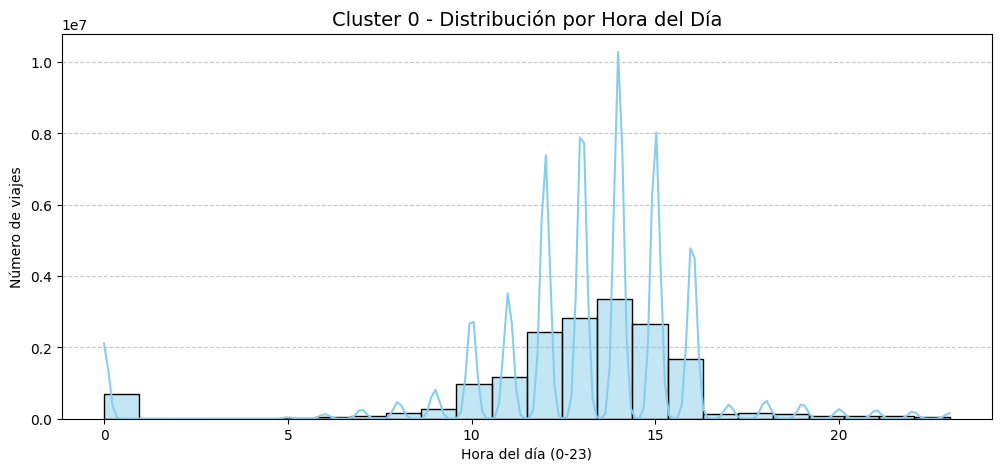

<ipython-input-1-9129e2e3c3b9>:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_counts.index, y=day_counts.values, palette='viridis')


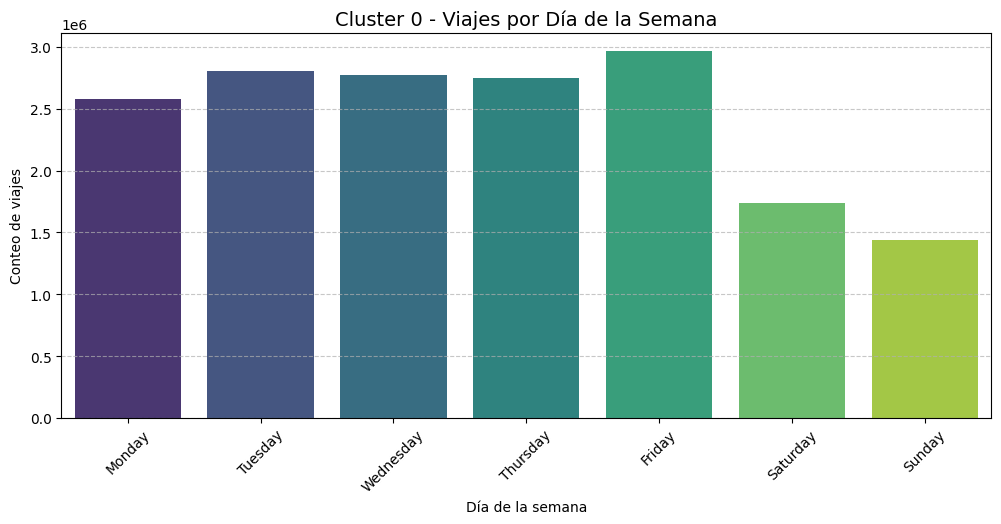


Análisis para Cluster 1


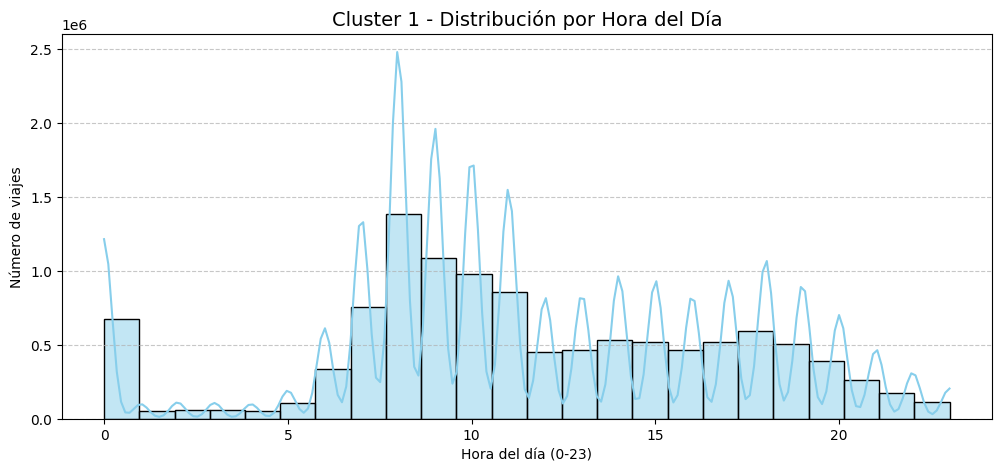

<ipython-input-1-9129e2e3c3b9>:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_counts.index, y=day_counts.values, palette='viridis')


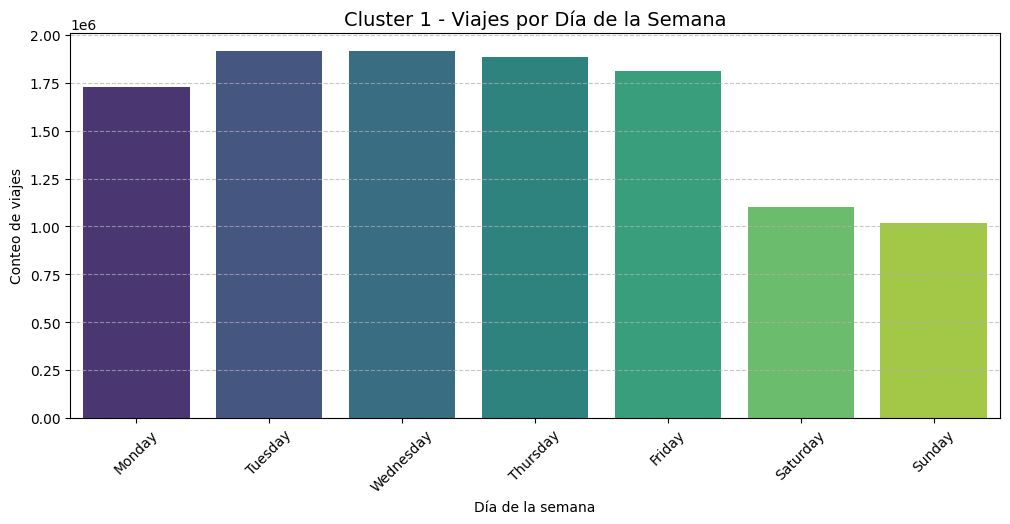


Análisis para Cluster 2


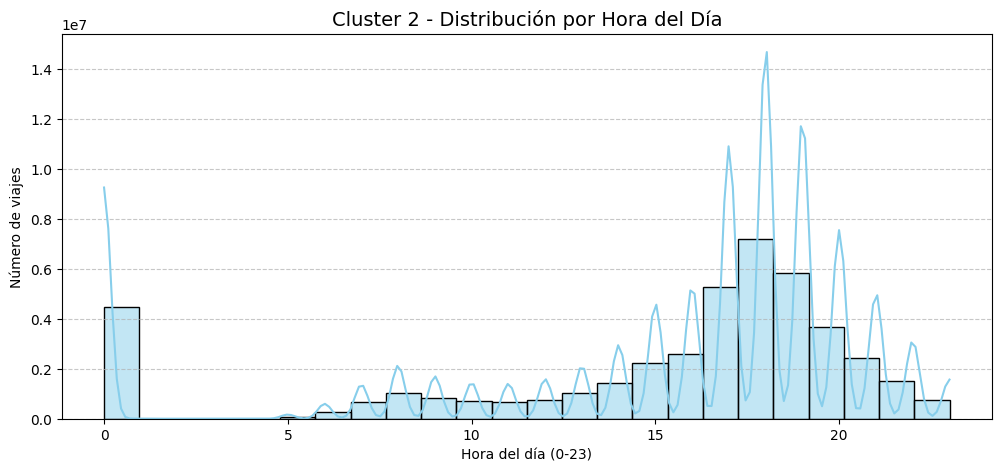

<ipython-input-1-9129e2e3c3b9>:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_counts.index, y=day_counts.values, palette='viridis')


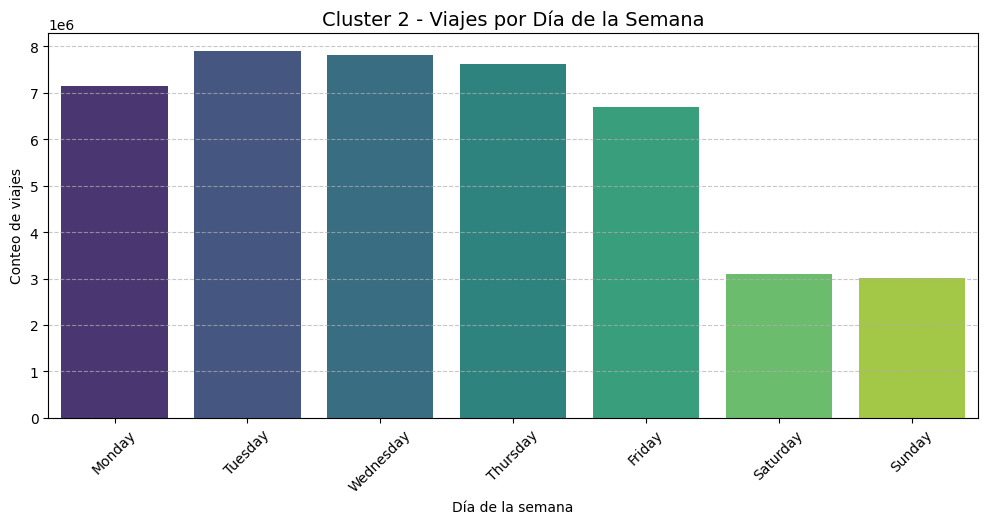


Análisis para Cluster 3


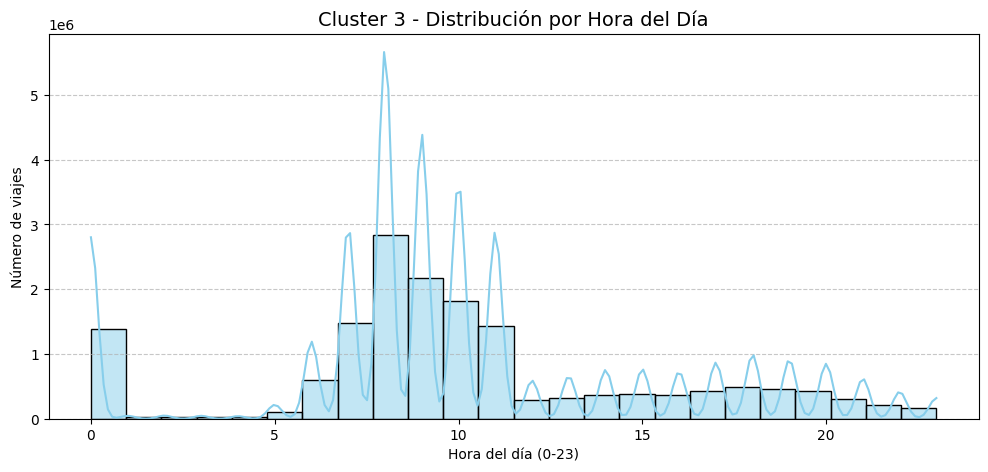

<ipython-input-1-9129e2e3c3b9>:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_counts.index, y=day_counts.values, palette='viridis')


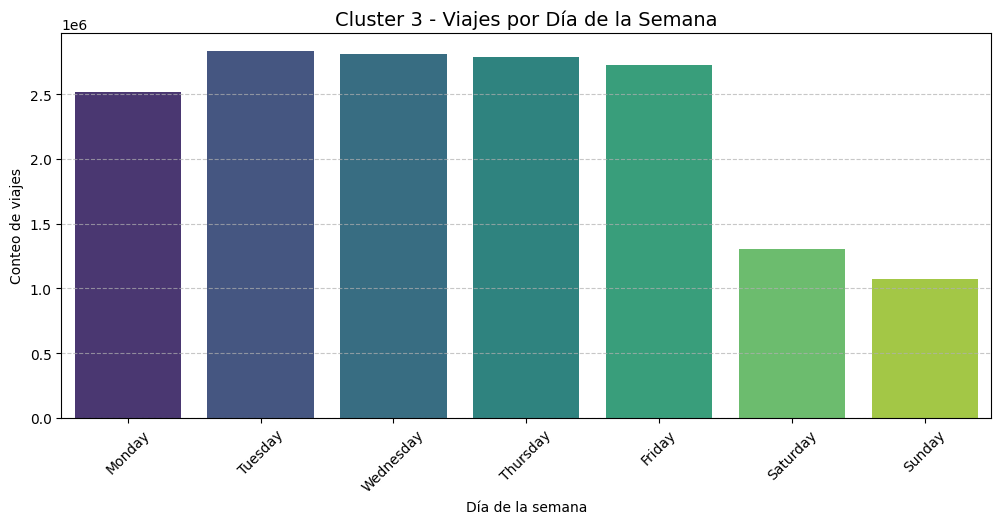


Análisis para Cluster 4


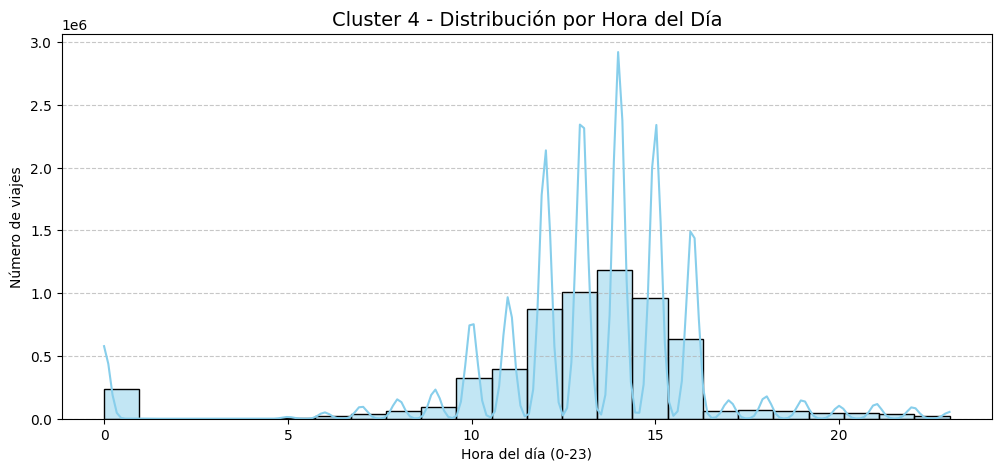

<ipython-input-1-9129e2e3c3b9>:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_counts.index, y=day_counts.values, palette='viridis')


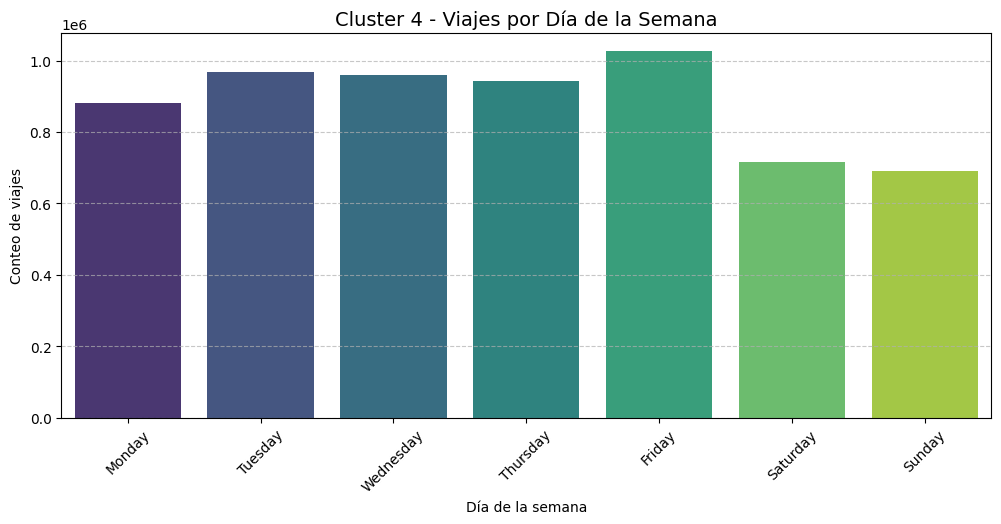

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# 1. Configuración
input_file = "/content/ecobici_perfilamiento_final.csv"
CHUNK_SIZE = 100_000
clusters_to_analyze = [0, 1, 2, 3, 4]

# 2. Diccionarios para acumular datos
hour_data = {cluster: [] for cluster in clusters_to_analyze}
day_data = {cluster: [] for cluster in clusters_to_analyze}

# 3. Procesar por chunks con barra de progreso
total_rows = sum(1 for _ in open(input_file)) - 1

with tqdm(total=total_rows, desc="Procesando datos") as pbar:
    for chunk in pd.read_csv(input_file, chunksize=CHUNK_SIZE,
                           usecols=['Cluster', 'Hora_Retiro', 'Dia_Semana'],
                           low_memory=False):
        for cluster in clusters_to_analyze:
            # Filtrar el chunk por cluster
            cluster_chunk = chunk[chunk['Cluster'] == cluster]

            # Acumular datos para histogramas
            hour_data[cluster].extend(cluster_chunk['Hora_Retiro'].dropna().tolist())
            day_data[cluster].extend(cluster_chunk['Dia_Semana'].dropna().tolist())

        pbar.update(len(chunk))

# 4. Visualización por cluster
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

for cluster in clusters_to_analyze:
    print(f"\n{'='*40}\nAnálisis para Cluster {cluster}\n{'='*40}")

    if not hour_data[cluster]:
        print(f"⚠️ No hay datos para el Cluster {cluster}")
        continue

    # --- Gráfico 1: Distribución por hora ---
    plt.figure(figsize=(12, 5))
    sns.histplot(x=hour_data[cluster], bins=24, kde=True, color='skyblue')
    plt.title(f'Cluster {cluster} - Distribución por Hora del Día', fontsize=14)
    plt.xlabel('Hora del día (0-23)')
    plt.ylabel('Número de viajes')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # --- Gráfico 2: Distribución por día ---
    plt.figure(figsize=(12, 5))
    day_counts = pd.Series(day_data[cluster]).value_counts().reindex(day_order, fill_value=0)
    sns.barplot(x=day_counts.index, y=day_counts.values, palette='viridis')
    plt.title(f'Cluster {cluster} - Viajes por Día de la Semana', fontsize=14)
    plt.xlabel('Día de la semana')
    plt.ylabel('Conteo de viajes')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
from collections import defaultdict
from tqdm.notebook import tqdm

# 1. Configuración
input_file = "/content/ecobici_perfilamiento_final.csv"
CHUNK_SIZE = 50_000
USECOLS = ['Cluster', 'Hora_Retiro', 'Dia_Semana', 'Edad_Estandarizada', 'Genero_M']

# 2. Diccionarios para estadísticas
stats = defaultdict(lambda: {
    'horas': [],
    'dias': [],
    'suma_edades': 0.0,
    'count_edades': 0,
    'suma_generos': 0.0
})

# 3. Procesar por chunks
total_rows = sum(1 for _ in open(input_file)) - 1

with tqdm(total=total_rows, desc="Procesando") as pbar:
    for chunk in pd.read_csv(input_file,
                           chunksize=CHUNK_SIZE,
                           usecols=USECOLS,
                           low_memory=False):
        # Liberar memoria inmediatamente después de usar el chunk
        chunk_groups = chunk.groupby('Cluster')
        for cluster, group in chunk_groups:
            stats[cluster]['horas'].extend(group['Hora_Retiro'].dropna().tolist())
            stats[cluster]['dias'].extend(group['Dia_Semana'].dropna().tolist())

            # Cálculo incremental para evitar almacenar todas las edades
            edades_validas = group['Edad_Estandarizada'].dropna()
            stats[cluster]['suma_edades'] += edades_validas.sum()
            stats[cluster]['count_edades'] += len(edades_validas)

            stats[cluster]['suma_generos'] += group['Genero_M'].sum()

        del chunk, chunk_groups  # Liberar memoria
        pbar.update(CHUNK_SIZE)

# 4. Recuperar edad real
try:
    from joblib import load
    scaler = load("/content/drive/MyDrive/scaler.joblib")
    mean_edad = scaler.mean_[2]
    std_edad = scaler.scale_[2]
except:
    mean_edad, std_edad = 0, 1
    print("No se encontró el scaler. Usando valores escalados.")

# 5. Función para desescalar edad
def desescalar_edad(edad_estandarizada):
    return (edad_estandarizada * std_edad) + mean_edad

# 6. Mostrar resultados corregidos
for cluster in sorted(stats.keys()):
    print(f"\n--- Cluster {cluster} ---")
    print(f"Horario pico: {pd.Series(stats[cluster]['horas']).mode()[0]}:00")
    print(f"Día más activo: {pd.Series(stats[cluster]['dias']).mode()[0]}")

    if stats[cluster]['count_edades'] > 0:
        edad_promedio = desescalar_edad(stats[cluster]['suma_edades'] / stats[cluster]['count_edades'])
        print(f"Edad promedio: {edad_promedio:.1f} años")
    else:
        print("Edad promedio: No disponible")

    print(f"Género predominante: {'M' if (stats[cluster]['suma_generos']/stats[cluster]['count_edades']) > 0.5 else 'F'}")

# 7. Guardar resultados optimizado
resultados = []
for cluster in sorted(stats.keys()):
    resultados.append({
        'Cluster': cluster,
        'Horario_Pico': pd.Series(stats[cluster]['horas']).mode()[0],
        'Dia_Mas_Activo': pd.Series(stats[cluster]['dias']).mode()[0],
        'Edad_Promedio': desescalar_edad(stats[cluster]['suma_edades'] / stats[cluster]['count_edades']) if stats[cluster]['count_edades'] > 0 else None,
        'Porcentaje_Masculino': f"{(stats[cluster]['suma_generos']/stats[cluster]['count_edades'])*100:.1f}%" if stats[cluster]['count_edades'] > 0 else "N/A"
    })

pd.DataFrame(resultados).to_csv("/content/resumen_clusters.csv", index=False)
print("Análisis completado y guardado!")

Procesando:   0%|          | 0/94800000 [00:00<?, ?it/s]


--- Cluster 0.0 ---
Horario pico: 14.0:00
Día más activo: Friday
Edad promedio: 0.2 años
Género predominante: M

--- Cluster 1.0 ---
Horario pico: 8.0:00
Día más activo: Tuesday
Edad promedio: 0.1 años
Género predominante: F

--- Cluster 2.0 ---
Horario pico: 18.0:00
Día más activo: Tuesday
Edad promedio: 0.0 años
Género predominante: M

--- Cluster 3.0 ---
Horario pico: 8.0:00
Día más activo: Tuesday
Edad promedio: 0.2 años
Género predominante: M

--- Cluster 4.0 ---
Horario pico: 14.0:00
Día más activo: Friday
Edad promedio: -0.0 años
Género predominante: F
Análisis completado y guardado!


Preparando datos para heatmap: 0it [00:00, ?it/s]

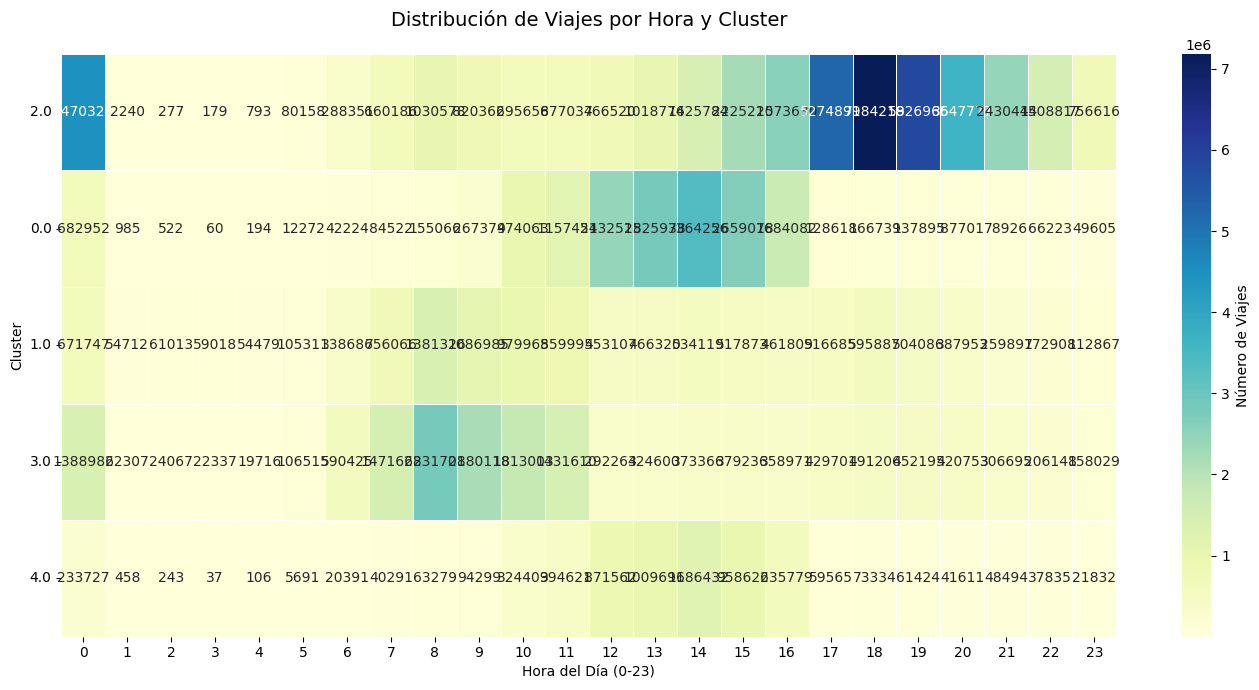

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# 1. Configuración
input_file = "/content/ecobici_perfilamiento_final.csv"
CHUNK_SIZE = 100_000

# 2. Diccionario para acumular conteos
heatmap_counts = {}

# 3. Procesar por chunks
with tqdm(desc="Preparando datos para heatmap") as pbar:
    for chunk in pd.read_csv(input_file,
                          chunksize=CHUNK_SIZE,
                          usecols=['Hora_Retiro', 'Cluster'],
                          low_memory=False):
        # Agrupar y acumular
        grouped = chunk.groupby(['Hora_Retiro', 'Cluster']).size()
        for (hora, cluster), count in grouped.items():
            if hora not in heatmap_counts:
                heatmap_counts[hora] = {}
            heatmap_counts[hora][cluster] = heatmap_counts[hora].get(cluster, 0) + count
        pbar.update(len(chunk))

# 4. Convertir a DataFrame
heatmap_data = pd.DataFrame.from_dict(heatmap_counts, orient='index')
heatmap_data = heatmap_data.sort_index().fillna(0)

# 5. Visualización optimizada
plt.figure(figsize=(14, 7))
sns.heatmap(heatmap_data.T,
           cmap='YlGnBu',
           annot=True,
           fmt='.0f',
           linewidths=0.5,
           cbar_kws={'label': 'Número de Viajes'})

plt.title('Distribución de Viajes por Hora y Cluster', pad=20, fontsize=14)
plt.xlabel('Hora del Día (0-23)')
plt.ylabel('Cluster')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
